# QF 627 Programming and Computational Finance
## Mock Assessment: Comprehensive Practice Exam

***

> Good day, Team 👋

> This mock assessment is designed to simulate the actual exam and help you prepare effectively. It covers all the key topics from the course: **data wrangling**, **rule-based algorithmic trading**, **supervised learning**, and **unsupervised learning** (PCA, t-SNE, K-Means clustering, and agglomerative hierarchical clustering).

> The purpose of this assessment is to:
> - Help you gauge your understanding of the course material
> - Practice applying concepts in a timed environment
> - Identify areas that may need additional review

> This is a **practice exam** and will not be graded. Use it as an opportunity to strengthen your knowledge and build confidence.

***

> **Time allocation**: You have **3 hours** to complete this assessment.

> **Format**: This is an open-book assessment. You may refer to your notes, course materials, and documentation.

> **Submission**: Save your completed notebook with your last name (e.g., `YourLastName_MockExam.ipynb`)

> **Important**: If you cannot answer a question, move on to the next one and return later if time permits. Make the best use of your time.

***

> I wish you the best in your preparation 🤞

***

### For standardization of your answers…

> Please execute the lines of code below before you start work on your answers.

In [341]:
# Our standardized printing options

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

np.set_printoptions(precision = 3)

pd.set_option("display.float_format", lambda x: "%.3f" % x)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## List of Questions

    IMPORTANT NOTE: 

### <font color = purple> <center> One of the key aspects of the current assessment involves data wrangling. 

### <font color = purple> <center> Please ensure that you correctly wrangle your data to obtain valid answers.

### <font color = purple> <center> When using a function, please write the function within the current script.

***
# SECTION A: Rule-Based Algorithmic Trading & Performance Metrics
***

##  <font color = blue> 👉 Question 1. </font> Data Import and Wrangling (10 points)

### You will be working with three stock datasets for this section. Please download the following tickers from Yahoo Finance for the period **January 1, 2015 to December 31, 2020**:

- **Stock X**: Apple Inc. (AAPL)
- **Stock Y**: Microsoft Corporation (MSFT)  
- **Stock Z**: Tesla Inc. (TSLA)

### Tasks:

a) Download the data using `yfinance` or `pandas_datareader`

b) Check for missing values and handle them appropriately using forward-fill method

c) Display the first 5 rows and last 5 rows of each dataset

d) Report the total number of trading days for each stock in the dataset

### Use `Adj Close` price for all subsequent calculations.

### Below are the lines of code that lead to an answer:

In [342]:
# TODO yf download
def download_yf_data(tickers, start_date, end_date, column='Close'):
    """
    Download AAPL stock data from Yahoo Finance
    download_yf_data(['AAPL'], '2020-01-01', '2021-01-01', ['Close'])
    """
    stock_data = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        threads=True
    )
    return stock_data[column]

# Example usage
# download_yf_data(['AAPL'], '2020-01-01', '2021-01-01', ['Close'])

### IMPORT

In [343]:
import yfinance as yf
import datetime as dt

# Your code here
start_date = "2015-01-01"
end_date = "2020-12-31"

In [344]:
tickers = ['AAPL', 'MSFT', 'GOOGL']

stock_data = download_yf_data(tickers, start_date, end_date, ['Close'])

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_83551/2877424014.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(
[*********************100%***********************]  3 of 3 completed


In [345]:
# Download data for Stock X (AAPL)
stock_dct = {}
for ticker in tickers:
    stock_dct[ticker] = stock_data['Close'][[ticker]]
    display(stock_dct[ticker])
    display(stock_dct[ticker].shape)

Ticker,AAPL
Date,
2015-01-02,24.261
2015-01-05,23.578
2015-01-06,23.580
2015-01-07,23.910
2015-01-08,24.829
...,...
2020-12-23,127.607
2020-12-24,128.591
2020-12-28,133.190


(1510, 1)

Ticker,MSFT
Date,
2015-01-02,39.933
2015-01-05,39.566
2015-01-06,38.985
2015-01-07,39.480
2015-01-08,40.642
...,...
2020-12-23,212.474
2020-12-24,214.137
2020-12-28,216.262


(1510, 1)

Ticker,GOOGL
Date,
2015-01-02,26.296
2015-01-05,25.795
2015-01-06,25.158
2015-01-07,25.084
2015-01-08,25.172
...,...
2020-12-23,85.820
2020-12-24,86.114
2020-12-28,88.090


(1510, 1)

In [347]:
for ticker, df in stock_dct.items():
    missing = df.isnull().sum().sum()
    print(f"{ticker}: {missing} missing values")
    if missing > 0:
        stock_dct[ticker] = df.ffill()

AAPL: 0 missing values
MSFT: 0 missing values
GOOGL: 0 missing values


### <font color = red> Answer 1 </font>

    Stock X (AAPL) has ____________ trading days.
    
    Stock Y (MSFT) has ____________ trading days.
    
    Stock Z (TSLA) has ____________ trading days.
    
    Missing values handled using: ____________ method.

In [7]:
for ticker, df in stock_dct.items():
    print(f"    {ticker} has {len(df)} trading days.")

    AAPL has 1510 trading days.
    MSFT has 1510 trading days.
    GOOGL has 1510 trading days.


##  <font color = blue> 👉 Question 2. </font> Implementing a Momentum Strategy with Bollinger Bands (25 points)

### Implement a mean-reversion trading strategy using Bollinger Bands for **Stock X (AAPL)**:

### Strategy Rules:
- Calculate a 20-day Simple Moving Average (SMA)
- Calculate the upper band: SMA + (2 × 20-day standard deviation)
- Calculate the lower band: SMA - (2 × 20-day standard deviation)
- **Signal Generation**:
  - Buy signal (Signal = 1): When price crosses below the lower band
  - Sell signal (Signal = 0): When price crosses above the upper band
  - Hold (Signal = previous signal): Otherwise

### For rolling statistics, set `min_periods` at `20` and `center` argument at `False`.

### Assume you start with a **$100,000** capital and trade **500 shares** when the signal is 1.

### Tasks:

a) Create the Bollinger Bands and generate trading signals

b) Calculate the position (500 × signal, shifted by 1 day)

c) Calculate the strategy P&L

d) Report the total P&L from this strategy

e) Visualize the stock price along with the Bollinger Bands and trading signals

### Below are the lines of code that lead to an answer:

In [8]:
aapl = stock_dct['AAPL']

In [348]:
def get_sma(df, sma_list, min_periods=1):
    """
    Take DF and given list of SMA to enrich df when stock price is in first column
    """
    for window in sma_list:
        df[f"sma_{window}"] =\
        (
            df[df.columns[0]]
            .rolling(window = window,
                    min_periods = min_periods,
                    center=False)
            .mean()
        )

    return df

In [349]:
def create_bollinger_strategy(df, 
                              window = 20,
                              num_std = 2):
    """
    Create a Bollinger Band mean-reversion trading strategy
    """
    df = get_sma(df, [window], 20)
    std = df[df.columns[0]].rolling(20).std()
    df = df.dropna()
    # print(df[f'sma_{window}'])
    df['upper'] = df[f'sma_{window}'] + num_std * std
    df['lower'] = df[f'sma_{window}'] - num_std * std

    df['positions'] =\
    (
        np.where(
            df[df.columns[0]] < df['lower'], 1, 
                np.where(
                    df[df.columns[0]] > df['upper'], 0, np.nan
                        # np.where(
                        #     (df[df.columns[0]] < df[f'sma_{window}']) & (df[df.columns[0]] > df[f'sma_{window}']).shift(1), 0,
                        #         np.where(
                        #             (df[df.columns[0]] > df[f'sma_{window}']) & (df[df.columns[0]] < df[f'sma_{window}']).shift(1), 0, np.nan
                        #         )
                        # )
                )
        )
    )
    df['positions'] = df['positions'].ffill().shift(1).fillna(0)
    
    return df

aapl = create_bollinger_strategy(aapl.dropna())

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_83551/2755125158.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"sma_{window}"] =\


In [11]:
def get_returns_log(df, position_shift):
    """
    Log returns, given a list of positions and stock price in first column
    Usage: get_returns_log(aapl, 0)
    """
    df['positions'] = df['positions'].shift(position_shift)      # IMPORTANT
    df['trade'] = \
    (
        df['positions'].diff().fillna(0)
    )
    if df.at[df.index[0], 'positions'] != 0:
        df.at[df.index[0], 'trade'] = df.at[df.index[0], 'positions']
    df['passive_returns'] = \
    (
        np.log(
            df[df.columns[0]] / 
                df[df.columns[0]].shift(1)
        )
    ).fillna(0)
    df['strategy_returns'] = \
    (
        df['passive_returns'] * df['positions'].fillna(0)
    )
    df['cum_passive_returns'] = \
    (
        df['passive_returns'].cumsum().apply(np.exp).fillna(1)
    )
    df['cum_strategy_returns'] = \
    (
        df['strategy_returns'].cumsum().apply(np.exp).fillna(1)
    )
    

    return df

In [350]:
# Apply the strategy to Stock X
aapl = get_returns_log(aapl, 0)

In [351]:
shares = 500
aapl['pnl'] = aapl[aapl.columns[0]].diff() * aapl['positions'] * 500

In [352]:
aapl['pnl'].sum()

np.float64(14915.973663330078)

In [353]:
# aapl['cum_strategy_returns'] = 100_000 + aapl.pnl.cumsum()

In [16]:
# Calculate total P&L
def get_cagr(cumulative_returns):
    """
    get_cagr Compute Compound Annual Growth Rate (CAGR) from a series of cumulative returns.
        - The function drops missing values and uses the first and last available
      observations to compute CAGR as:
          (last_value / first_value) ** (365.0 / n_days) - 1
      where n_days is the integer number of days between the first and last index.
        - Uses 365-day convention for annualization. For trading-day conventions
        adjust the exponent accordingly.
        - If the series contains a single observation or zero-day span, the result
        may be ill-defined (division by zero or power of inf). Consider checking
        the index span before calling.
    Parameters:
        cumulative_returns : pandas.Series. Time-indexed series of cumulative returns (e.g. cumulative growth factors)
    Returns:
        float
    """

    cumulative_returns = cumulative_returns.dropna()
    n_of_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]
                ).days
    cagr =\
    (
        (        
        cumulative_returns.iloc[-1] 
        /
        cumulative_returns.iloc[0]
        ) ** (365.25 / n_of_days)
        - 1
    )
    return cagr

# print(f"The answer is {max(c_dct, key=c_dct.get).upper()} with {max(c_dct.values()):.2%}")

In [17]:
# Visualization

### <font color = red> Answer 2 </font>

    Total P&L for Stock X (AAPL) using Bollinger Band strategy: $____________
    
    Initial Capital: $100,000
    
    Final Portfolio Value: $____________
    
    Return: ____________%

In [18]:
# TODO get_plot lets-plot; basic 
from lets_plot import *
LetsPlot.setup_html()

aapl_melt = aapl.reset_index()
# aapl_melt = aapl_melt.rename(columns={'index':'Date'}). # optional depending if index is called 'Date'

p =\
(
    ggplot(aapl_melt, aes(x='Date')) +
    geom_line(aes(y='AAPL'), color='grey', size=0.7) +
    geom_line(aes(y='upper'), color='orange', size=0.5,linetype=1) +   # amend sma as required
    geom_line(aes(y='lower'), color='blue', size=0.5,linetype=1) +
    geom_point(aes(y='AAPL'), data=aapl_melt[aapl_melt['trade']>0.0], color='green', size=3) +       # amend trade as required
    geom_point(aes(y='AAPL'), data=aapl_melt[aapl_melt['trade']<-0.0], color='red', size=3) +
    ggtitle("Price Action with Signals") +
    ylab("Stock Price") +
    xlab("Date") +
    ggsize(1200, 500) 
)


p

In [19]:
print(f"    Total P&L for Stock X (AAPL) using Bollinger Band strategy: ${aapl.pnl.sum()}")
print(f"    Initial Capital: $100,000")
print(f"    Final Portfolio Value: ${100_000+aapl.pnl.sum()}")
print(f"    Return: {get_cagr(aapl['cum_strategy_returns']):.2%}")

    Total P&L for Stock X (AAPL) using Bollinger Band strategy: $14915.973663330078
    Initial Capital: $100,000
    Final Portfolio Value: $114915.97366333008
    Return: 9.86%


##  <font color = blue> 👉 Question 3. </font> Dual Moving Average Crossover Strategy (25 points)

### Implement a momentum strategy using dual moving averages for **Stock Y (MSFT)** and **Stock Z (TSLA)**:

### Strategy Rules:
- Calculate a 50-day Simple Moving Average (SMA_50)
- Calculate a 200-day Simple Moving Average (SMA_200)
- **Signal Generation**:
  - Buy signal (Signal = 1): When SMA_50 > SMA_200
  - Sell signal (Signal = 0): When SMA_50 < SMA_200

### For rolling statistics, set `min_periods` at `1` and `center` argument at `False`.

### Assume you start with **$100,000** capital for each stock and trade **300 shares** when signal is 1.

### Tasks:

a) Implement the dual moving average strategy for both stocks

b) Calculate the total P&L for each stock

c) Compare which stock performed better with this strategy

d) Calculate the annualized Sharpe ratio for each strategy (assume 252 trading days)

e) Which strategy has a better risk-adjusted return?

### Below are the lines of code that lead to an answer:

In [20]:
stock_dct.pop('AAPL')

Ticker,AAPL
Date,
2015-01-02,24.261
2015-01-05,23.578
2015-01-06,23.580
2015-01-07,23.910
2015-01-08,24.829
...,...
2020-12-23,127.607
2020-12-24,128.591
2020-12-28,133.190


In [21]:
def get_momentum_strategy(df, sma_tuple, shares = 1):
    """
    Apply single stock momentum strategy pipeline to price DataFrame `df`. 
    Price is in first column.
    Adds columns:
      positions, trade, passive_returns, strategy_returns,
      cum_returns, cum_strategy_returns
    Parameters:
      df        : pd.DataFrame with price columns for ticker name as the header
      sma_tuple : tuple of (short_window, long_window) for SMAs
    Returns:
      pd.DataFrame with the above columns
    """
    def get_sma(df, sma_list):
        """
        Take DF and given list of SMA to enrich df when stock price is in first column
        """
        for window in sma_list:
            df[f"sma_{window}"] =\
            (
                df[df.columns[0]]
                .rolling(window = window,
                         min_periods = 1,
                         center = False)
                .mean()
            )

        return df
    sma_short, sma_long = sma_tuple
    if sma_short >= sma_long:
        raise ValueError("sma_short must be less than sma_long")
    df = get_sma(df, list(sma_tuple)).dropna()

    df['positions'] =\
    (
        np.where((df[f'sma_{sma_short}'] > df[f'sma_{sma_long}']), 1, 0)
    )
    df['positions'] = df['positions'].shift(1)
    df['trade'] = \
    (
        df['positions'].diff().fillna(0)
    )
    if df.at[df.index[0], 'positions'] != 0:
        df.at[df.index[0], 'trade'] = df.at[df.index[0], 'positions']
    df['passive_returns'] =\
    (    # get passive returns
        np.log(df[df.columns[0]] 
            / df[df.columns[0]].shift(1))
    ).fillna(0)
    df['strategy_returns'] =\
    (     # get strategy returns
        df['passive_returns'] * df['positions'].fillna(0)
    )
    df['cum_returns'] =\
    (
        df['passive_returns'].cumsum().apply(np.exp).fillna(1)
    )
    df['cum_strategy_returns'] =\
    (
        df['strategy_returns'].cumsum().apply(np.exp).fillna(1)
    )
    df['pnl'] = df[df.columns[0]].diff() * shares * df['positions']

    return df


In [356]:
stock_dct['AAPL']

Ticker,AAPL,sma_50,sma_200,positions,trade,passive_returns,strategy_returns,cum_returns,cum_strategy_returns,pnl
Date,,,,,,,,,,
2015-01-02,24.261,24.261,24.261,NaN,NaN,0.000,0.000,1.000,1.000,NaN
2015-01-05,23.578,23.919,23.919,0.000,0.000,-0.029,-0.000,0.972,1.000,-0.000
2015-01-06,23.580,23.806,23.806,0.000,0.000,0.000,0.000,0.972,1.000,0.000
2015-01-07,23.910,23.832,23.832,0.000,0.000,0.014,0.000,0.986,1.000,0.000
2015-01-08,24.829,24.032,24.032,0.000,0.000,0.038,0.000,1.023,1.000,0.000
...,...,...,...,...,...,...,...,...,...,...
2020-12-23,127.607,116.395,96.040,1.000,0.000,-0.007,-0.007,5.260,3.377,-268.945
2020-12-24,128.591,116.609,96.382,1.000,0.000,0.008,0.008,5.300,3.403,295.244
2020-12-28,133.190,116.925,96.711,1.000,0.000,0.035,0.035,5.490,3.525,1379.750


In [357]:
sma_tup = (50, 200)

for ticker, df in stock_dct.items():
    stock_dct[ticker] = get_momentum_strategy(df, sma_tup, shares=300)
    print(f"Ticker: {ticker}: Total P&L = ${stock_dct[ticker]['pnl'].sum():,.2f}")

Ticker: AAPL: Total P&L = $26,707.63
Ticker: MSFT: Total P&L = $48,553.48
Ticker: GOOGL: Total P&L = $10,497.20


/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_83551/2176740718.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['positions'] =\
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_83551/2176740718.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['positions'] = df['positions'].shift(1)
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_83551/2176740718.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

In [358]:
# Apply to Stock Y (MSFT)

In [359]:
# Apply to Stock Z (TSLA)

In [360]:
def get_sharpe(daily_returns):
    """
    get_sharpe Calculate the annualized Sharpe ratio from a series of daily returns.
    Annualized Sharpe ratio computed as:
                sqrt(252) * mean(daily_returns) / std(daily_returns)
    - Assumes 252 trading days per year for annualization. Adjust the
      multiplier for a different convention.
    - Input should be returns (not prices). Convert prices to returns before
      calling this function.
    Parameters:
        daily_returns : array-like (pd.Series or np.ndarray)
    Returns:
        float
    Usage:
        compute_sharpe_ratio(df['strategy_returns'])
    """
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std(ddof = 1)

# compute_sharpe_ratio(ibm['strategy_returns'])
# print(f"The answer is {max(sharpe_dct, key=s_dct.get).upper()} with  {max(sharpe_dct.values()):.5f}")

In [361]:
# Calculate Sharpe ratios

### <font color = red> Answer 3 </font>

    Stock Y (MSFT):
    - Total P&L: $____________
    - Sharpe Ratio: ____________
    
    Stock Z (TSLA):
    - Total P&L: $____________
    - Sharpe Ratio: ____________
    
    Better performing stock (by P&L): ____________
    
    Better risk-adjusted return (by Sharpe): ____________

In [362]:
for ticker, df in stock_dct.items():
    print(f"{ticker}")
    print(f"- Total P&L: ${df.pnl.sum():,.2f}")
    print(f"- Sharpe Ratio: {get_sharpe(df['strategy_returns']):.5f}")


print(f"    Better performing stock (by P&L): MSFT\nBetter risk-adjusted return (by Sharpe): MSFT")

AAPL
- Total P&L: $26,707.63
- Sharpe Ratio: 0.80060
MSFT
- Total P&L: $48,553.48
- Sharpe Ratio: 0.92587
GOOGL
- Total P&L: $10,497.20
- Sharpe Ratio: 0.47136
    Better performing stock (by P&L): MSFT
Better risk-adjusted return (by Sharpe): MSFT


##  <font color = blue> 👉 Question 4. </font> Drawdown Analysis (20 points)

### For **Stock X (AAPL)** using the Bollinger Band strategy from Question 2:

### Tasks:

a) Calculate the cumulative returns (wealth index)

b) Calculate the drawdown series

c) Report the maximum drawdown (as a percentage)

d) Calculate the longest drawdown period (in days)

e) Visualize the wealth curve and drawdown series

f) Calculate the Calmar ratio (CAGR / Maximum Drawdown)

### Below are the lines of code that lead to an answer:

In [363]:
aapl_momentum = get_momentum_strategy(aapl, sma_tup, shares = 300)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_83551/2176740718.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['positions'] =\
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_83551/2176740718.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['positions'] = df['positions'].shift(1)
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_83551/2176740718.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

In [364]:
def get_drawdowns_plot(df):
  df['daily_drawdown'] = df['cum_strategy_returns'] / df['cum_strategy_returns'].cummax() - 1
  # take date column out and cumsum for periods
  dd_reset = df.reset_index()
  dd_reset['period'] = (dd_reset['daily_drawdown'] == 0).cumsum()
  # find nodes with 0 value i.e. highpoints
  dd_nonzero = dd_reset[dd_reset['daily_drawdown'] != 0]
  # aggregate by period
  period_stats = dd_nonzero.groupby('period').agg(
      start_date = ('Date', 'min'),
      end_date = ('Date', 'max'),
      avg_dd = ('daily_drawdown', 'mean'),
      max_dd = ('daily_drawdown', 'min'),
      duration=('daily_drawdown', 'count')
  ).sort_values(by='avg_dd',ascending=True)


  ## printing drawdowns
  for i, row in enumerate(period_stats.itertuples(), start=1):
      ordinal = f"{i}{'tsnrhtdd'[i%5*(i%100^15>4>i%10)::4]}"
      print(f"The {ordinal} worst drawdown period : Net drawdown {-row.max_dd:.2%}% | Duration {row.duration} Days\n")


  # plot drawdowns
  # from lets_plot import *
  # LetsPlot.setup_html()
  p =\
  (
      ggplot(dd_reset, aes(x='Date')) +
      geom_line(aes(y='daily_drawdown'), color='grey', size=0.7) +
      # geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +   # amend sma as required
      # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
      # geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']>0.0], color='red', size=3) +       # amend trade as required
      # geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']<-0.0], color='blue', size=3) +
      ggtitle(f"Drawdown for {ticker}") +
      ylab("pct loss") +
      scale_y_continuous(format='.0%') + 
      xlab("Date") +
      ggsize(1200, 500) 
  )
  display(p)

  return period_stats

In [365]:
aapl_dd = get_drawdowns_plot(aapl_momentum)

The 1st worst drawdown period : Net drawdown 45.61%% | Duration 319 Days

The 2nd worst drawdown period : Net drawdown 31.43%% | Duration 78 Days

The 3rd worst drawdown period : Net drawdown 20.38%% | Duration 80 Days

The 4th worst drawdown period : Net drawdown 15.85%% | Duration 422 Days

The 5th worst drawdown period : Net drawdown 13.45%% | Duration 25 Days

The 6th worst drawdown period : Net drawdown 10.68%% | Duration 37 Days

The 7th worst drawdown period : Net drawdown 8.86%% | Duration 55 Days

The 8th worst drawdown period : Net drawdown 8.23%% | Duration 39 Days

The 9th worst drawdown period : Net drawdown 5.84%% | Duration 8 Days

The 10th worst drawdown period : Net drawdown 4.69%% | Duration 19 Days

The 11th worst drawdown period : Net drawdown 6.09%% | Duration 33 Days

The 12th worst drawdown period : Net drawdown 4.83%% | Duration 5 Days

The 13th worst drawdown period : Net drawdown 3.76%% | Duration 26 Days

The 14th worst drawdown period : Net drawdown 4.80%% |

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_83551/627837039.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['daily_drawdown'] = df['cum_strategy_returns'] / df['cum_strategy_returns'].cummax() - 1


In [366]:
def compute_cagr(df, 
                 price_column = "Adj Close"):
    """
    Calculate Compound Annual Growth Rate
    """
    start_value = df[price_column].iloc[0]
    end_value = df[price_column].iloc[-1]
    
    days = (df.index[-1] - df.index[0]).days
    years = days / 365.25
    
    cagr = (end_value / start_value) ** (1 / years) - 1
    
    return cagr * 100

### <font color = red> Answer 4 </font>

    Maximum Drawdown: ____________%
    
    Longest Drawdown Period: ____________ days
    
    CAGR: ____________%
    
    Calmar Ratio: ____________

<Axes: xlabel='Date'>

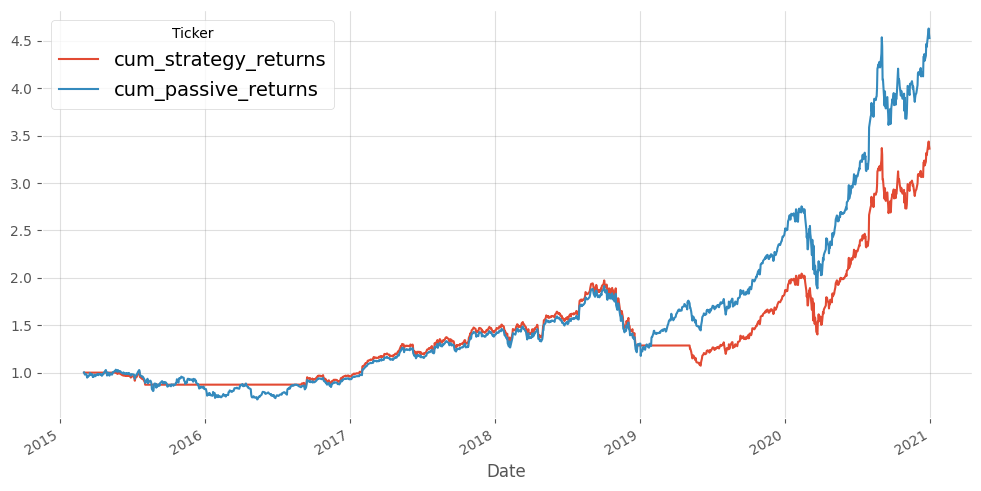

In [367]:
aapl_momentum[['cum_strategy_returns','cum_passive_returns']].plot(figsize=[12,6])

<Axes: xlabel='Date'>

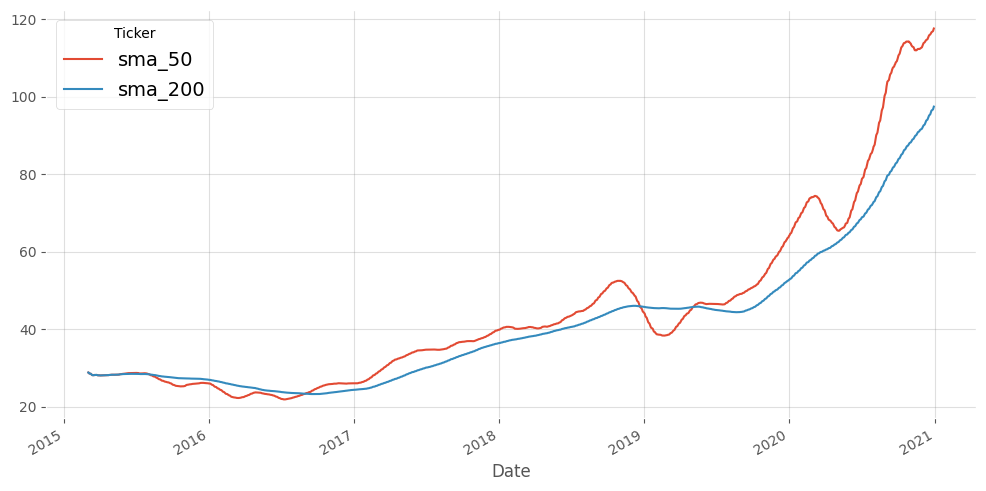

In [368]:
aapl_momentum[['sma_50','sma_200']].plot(figsize=[12,6])

In [74]:
print(f"    Maximum Drawdown: {-aapl_dd.max_dd.min():.2%}")
print(f"    Longest Drawdown Period: {aapl_dd.duration.max():.0f} days")
print(f"    CAGR: {get_cagr(aapl_momentum.cum_strategy_returns):.2%}")
print(f"    Calmar Ratio: {get_cagr(aapl_momentum.cum_strategy_returns) /(-aapl_dd.max_dd.min()) :.5f}")

    Maximum Drawdown: 45.61%
    Longest Drawdown Period: 421 days
    CAGR: 23.89%
    Calmar Ratio: 0.52369


***
# SECTION B: Supervised Learning
***

##  <font color = blue> 👉 Question 5. </font> Feature Engineering for Stock Price Prediction (25 points)

### Build a supervised learning model to predict the **weekly returns** of **Stock Y (MSFT)**.

### Feature Engineering Requirements:

**Target Variable (Y)**:
- Weekly return of MSFT (5-day return)

**Predictor Variables (X)**:

*Lagged Returns*:
- Lagged 5-day return of MSFT
- Lagged 10-day return of MSFT  
- Lagged 20-day return of MSFT

*Technical Indicators*:
- 21-day Simple Moving Average
- 50-day Simple Moving Average
- 14-day RSI (Relative Strength Index)
  - RSI = 100 - (100 / (1 + RS))
  - RS = Average Gain / Average Loss over 14 days

*Correlated Assets*:
- 5-day return of AAPL
- 5-day return of TSLA

### Tasks:

a) Engineer all the features listed above

b) Handle missing values (drop rows with NaN)

c) Split data: 70% training, 30% testing (use the first 70% for training chronologically)

d) Display the shape of training and testing sets

e) Show the first 5 rows of the feature matrix

### Below are the lines of code that lead to an answer:

In [85]:
msft = stock_data['Close']['MSFT']

In [93]:
target = 'MSFT'
stock_tickers = [
    "MSFT", "AAPL", "TSLA"    # Stocks
]
sub_df_list = stock_tickers 
ticker_data =\
(
    yf.download(
        sub_df_list,
        start = start_date,
        end = end_date,
        threads = True,
        auto_adjust=False
    )
)['Close']
# remove nulls
ticker_data = ticker_data.ffill()

[*********************100%***********************]  3 of 3 completed


In [97]:
sub_df_list = []

# 5 day lags for all stocks
df_rets = ticker_data[[ticker for ticker in stock_tickers if ticker != target]].copy() # remove target
lag = 5
df_rets = df_rets.pct_change(lag).shift(1).rename(columns={f'{ticker}':f'{ticker}_ret_{lag}' for ticker in stock_tickers})

sub_df_list.append(df_rets)

In [98]:
# # get ccy 
# sub_df_list.append(ticker_data[ccy_tickers].copy())
# # get indices
# sub_df_list.append(ticker_data[index_tickers].copy())

In [99]:

# lagged five-day, 10-day, and 20-day returns of NFLX.
lag_list = [5, 10, 20]
df_rets = ticker_data[[target]].copy()

for lag in lag_list:
    df_rets[f'{target}_ret_{lag}'] = df_rets[target].pct_change(lag).shift(1)
    
df_rets = df_rets.drop(columns=target)

sub_df_list.append(df_rets)

In [100]:
# get sma
def get_sma(df, sma_list):
    """
    Take DF and given list of SMA to enrich df when stock price is in first column
    """
    for window in sma_list:
        df[f"sma_{window}"] =\
        (
            df[df.columns[0]]
            .rolling(window = window,
                     min_periods = int(window * .8))
            .mean()
        )

    return df

sma_list = [21, 50]
df_sma = get_sma(ticker_data[[target]].copy(), sma_list).drop(columns=target)

sub_df_list.append(df_sma)



In [101]:
# get RSI
def get_rsi(df, period_list=[10, 30, 200]):
    """
    Calculate RSI (Relative Strength Index)
    
    Parameters:
    data: pandas df of closing price
    period: RSI period (default [10, 20, 200])
    
    Returns:
    pandas df with RSI values
    """
    # Calculate price changes
    delta = df[df.columns[0]].diff()
    
    for period in period_list:
        # Separate gains and losses
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        
        # get first average
        avg_gain = pd.Series(index=df.index, dtype='float64')
        avg_loss = pd.Series(index=df.index, dtype='float64')

        # get first average
        avg_gain.iloc[period] = gain.iloc[1:period+1].mean()    # start from period + 1 since diff() makes first NaN
        avg_loss.iloc[period] = loss.iloc[1:period+1].mean()

        # Calculate rolling averages
        for i in range(period + 1, len(df)): 
            avg_gain.iloc[i] = (avg_gain.iloc[i-1] * (period - 1) + gain.iloc[i]) / period
            avg_loss.iloc[i] = (avg_loss.iloc[i-1] * (period - 1) + loss.iloc[i]) / period

        # Calculate RS (Relative Strength)
        rs = avg_gain / avg_loss
        
        # Calculate RSI
        rsi = 100 - (100 / (1 + rs))

        df[f'rsi_{period}'] = rsi

    return df

rsi_list = [14]
df_rsi = get_rsi(ticker_data[[target]].copy(), rsi_list).drop(columns=target)

sub_df_list.append(df_rsi)

In [104]:
# y parameter
fwd = 5
df_fwd_rets = ticker_data[[target]].copy()

df_fwd_rets[f"{target}_fwd_rets"] = df_fwd_rets.pct_change(fwd).shift(-fwd-1) 
                        # get fwd rets, shift by same amount, only trade day after signal computed
    
df_fwd_rets = df_fwd_rets.drop(columns=target)
sub_df_list.append(df_fwd_rets)

In [105]:
# combine df
df =\
(
    pd.concat(sub_df_list,axis=1)
)
# fill forward for NaN
df =\
(
    df.ffill().dropna()
)

In [ ]:
# Feature engineering code here
X = df.drop(columns=[f'{target}_fwd_rets'])
y = df[[f'{target}_fwd_rets']]

In [115]:
# Train-test split (70-30)
# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=False)

[ a.shape for a in [X_train, X_test, y_train, y_test ]]

[(1029, 8), (442, 8), (1029, 1), (442, 1)]

### <font color = red> Answer 5 </font>

    Total number of features: ____________
    
    Training set shape: (____________, ____________)
    
    Testing set shape: (____________, ____________)
    
    Date range for training: ____________ to ____________
    
    Date range for testing: ____________ to ____________

In [ ]:
print(f"    Training set shape: {X_train.shape}")
print(f"    Testing set shape: {X_test.shape}")
print(f"    Date range for training: {df.index[0]} to {df.index[len(X_train)-1]}")
print(f"    Date range for testing: {df.index[-len(X_test)]} to {df.index[-1]}")

    Total number of features: 8
    Training set shape: (1029, 8)
    Testing set shape: (442, 8)
    Date range for training: 2015-03-02 00:00:00 to 2019-04-01 00:00:00
    Date range for testing: 2019-04-02 00:00:00 to 2020-12-30 00:00:00


##  <font color = blue> 👉 Question 6. </font> Model Training and Evaluation (30 points)

### Train and evaluate the following regression models on the data prepared in Question 5:

1. Linear Regression
2. LASSO Regression (alpha = 0.1)
3. Ridge Regression (alpha = 1.0)
4. Decision Tree Regressor
5. Random Forest Regressor (n_estimators = 100)

### Tasks:

a) Train all five models on the training data

b) Make predictions on both training and testing sets

c) Calculate Mean Squared Error (MSE) for each model on both sets

d) Calculate R² score for each model on both sets

e) Create a comparison visualization showing MSE for all models (bar chart)

f) Identify which model performs best on the test set

g) For the best model, create a scatter plot of actual vs predicted returns for the test set

### Below are the lines of code that lead to an answer:

In [35]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:

mse_results = {}

def get_mse_train_test(model, X_train, y_train, X_test, y_test, name=None):
    """
    Compute MSE on train and test and store results in mse_results.
    If name is not provided, use model class name.
    """
    global mse_results
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    y_test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    model_name = name or model.__class__.__name__
    if model_name == "GridSearchCV":
        model_name = str(type(model.best_estimator_)).split(".")[-1].replace("'>", "")
    

    mse_results[str(model_name)] = {
                                    'mse_train': mse_train, 
                                    'mse_test': mse_test,
                                    'r2_train': r2_train,
                                    'r2_test': r2_test
                                }

    print(f"Mean Squared Error (MSE) for {model_name}")
    print(f"MSE train: {mse_train:.6f}")
    print(f"MSE test: {mse_test:.6f}")
    print(f"R2 train: {r2_train:.6f}")
    print(f"R2 test: {r2_test:.6f}")

    return mse_train, mse_test, r2_train, r2_test

In [121]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'LASSO': Lasso(alpha = 0.1),
    'Ridge': Ridge(alpha = 1.0),
    'Decision Tree': DecisionTreeRegressor(random_state = 627),
    'Random Forest': RandomForestRegressor(n_estimators = 100, random_state = 627)
}

In [120]:
# Train models and store results
results = {
    'Model': [],
    'Train_MSE': [],
    'Test_MSE': [],
    'Train_R2': [],
    'Test_R2': []
}

# Your training and evaluation code here

In [126]:
for model_name, model in models.items():
    fit_model = model.fit(X_train, y_train)
    get_mse_train_test(fit_model, 
                   X_train, 
                   y_train, 
                   X_test,
                   y_test, 
                   name=model_name)

Mean Squared Error (MSE) for Linear Regression
MSE train: 0.000865
MSE test: 0.001416
R2 train: 0.039293
R2 test: -0.003642
Mean Squared Error (MSE) for LASSO
MSE train: 0.000900
MSE test: 0.001415
R2 train: 0.000000
R2 test: -0.003404
Mean Squared Error (MSE) for Ridge
MSE train: 0.000873
MSE test: 0.001406
R2 train: 0.030426
R2 test: 0.003149
Mean Squared Error (MSE) for Decision Tree
MSE train: 0.000000
MSE test: 0.002614
R2 train: 1.000000
R2 test: -0.853007


/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mean Squared Error (MSE) for Random Forest
MSE train: 0.000087
MSE test: 0.001887
R2 train: 0.903579
R2 test: -0.337532


In [127]:
# Create results dataframe
metrics = pd.DataFrame(mse_results).T.sort_values(by='mse_test')
metrics['mse_ratio'] = metrics['mse_test'] / metrics['mse_train']
metrics

,mse_train,mse_test,r2_train,r2_test,mse_ratio
Ridge,0.001,0.001,0.030,0.003,1.611
LASSO,0.001,0.001,0.000,-0.003,1.572
Linear Regression,0.001,0.001,0.039,-0.004,1.637
Random Forest,0.000,0.002,0.904,-0.338,21.733
Decision Tree,0.000,0.003,1.000,-0.853,inf


/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


/Users/ju/Projects/qf627/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


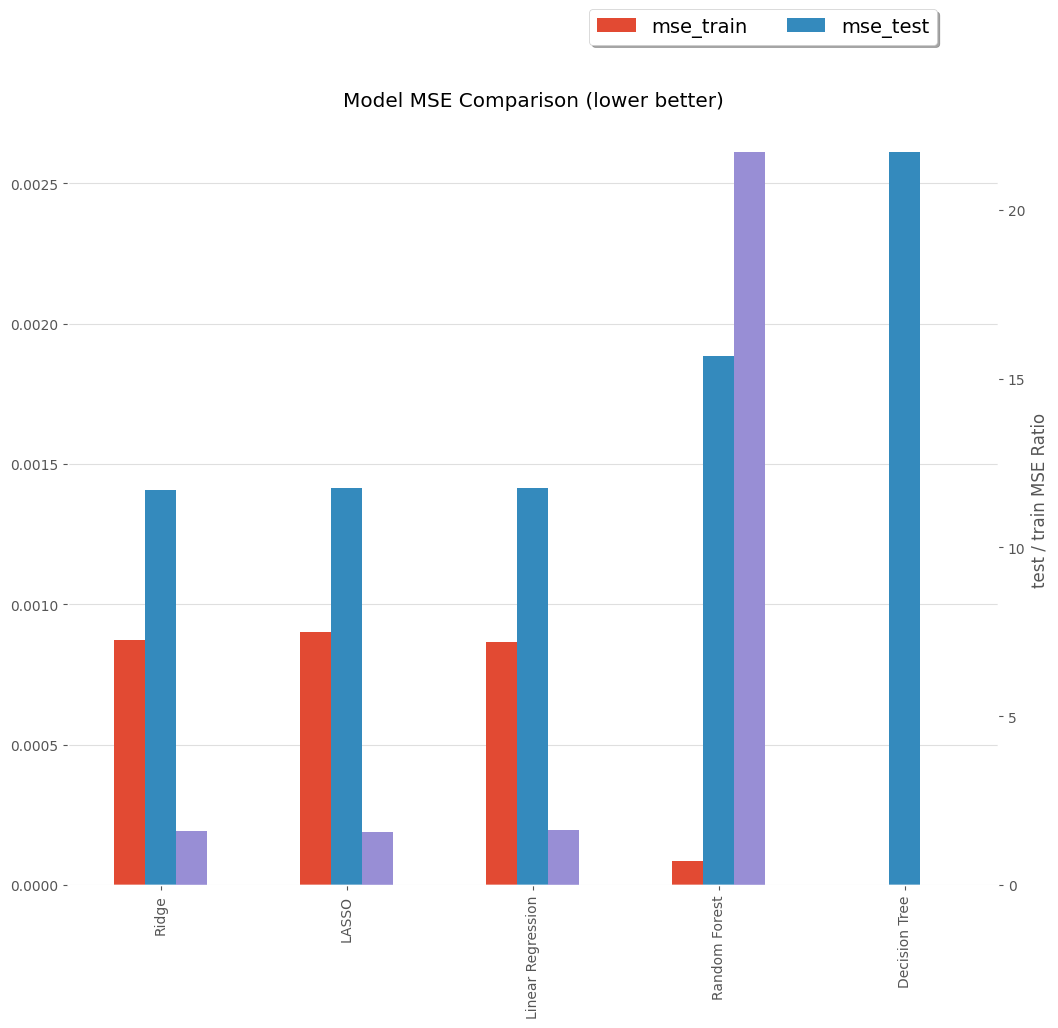

In [131]:
# Visualization of model comparison
ax =\
(
    metrics[['mse_train',	'mse_test', 'mse_ratio']].plot(
        secondary_y = 'mse_ratio',
        kind='bar',
        title='Model MSE Comparison (lower better)',
        ylabel='test / train MSE Ratio',
        figsize=(12, 10)
    )
)

ax.xaxis.grid(False)

(
    ax
    .legend(loc = "upper left",
            bbox_to_anchor = (0.55, 1.15),
            ncol = 4,
            shadow = True
           )
)

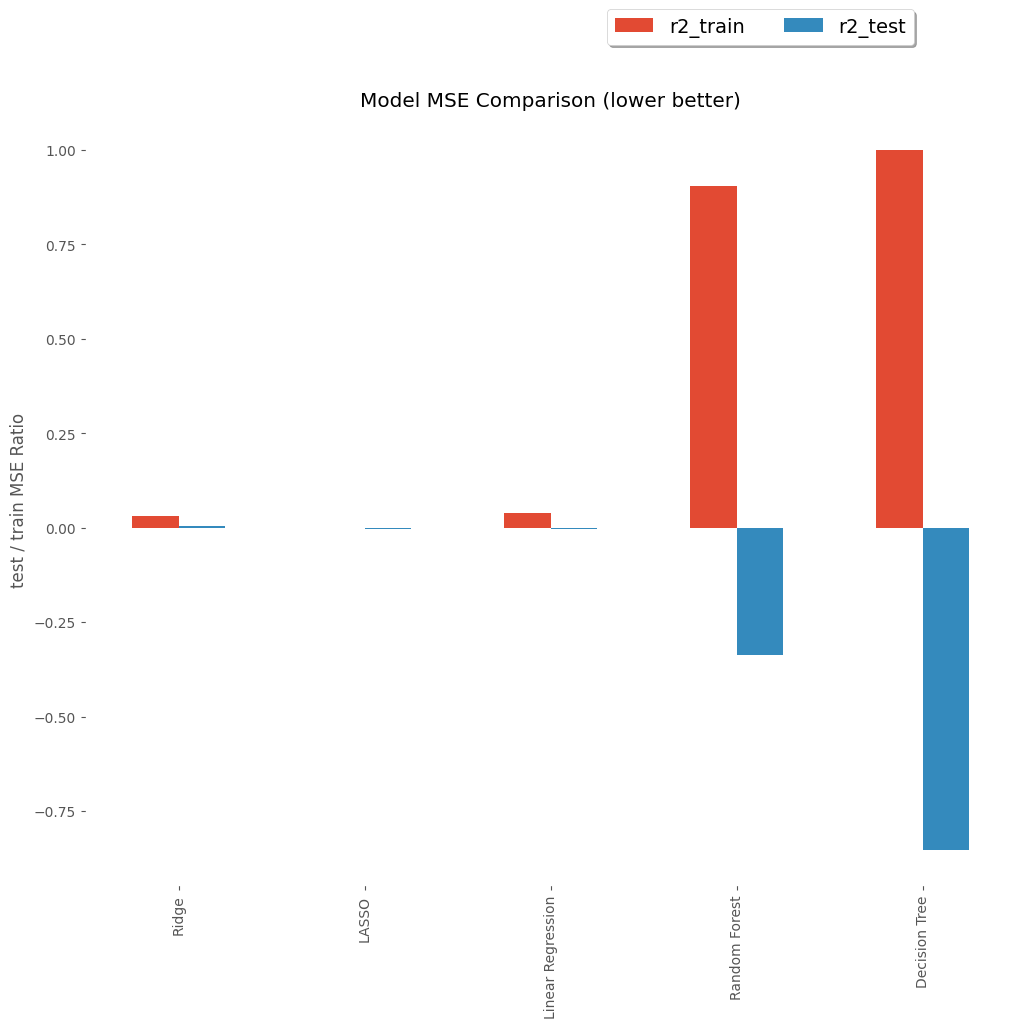

In [132]:
# Visualization of model comparison
ax =\
(
    metrics[['r2_train',	'r2_test']].plot(
        secondary_y = 'mse_ratio',
        kind='bar',
        title='Model MSE Comparison (lower better)',
        ylabel='test / train MSE Ratio',
        figsize=(12, 10)
    )
)

ax.xaxis.grid(False)

(
    ax
    .legend(loc = "upper left",
            bbox_to_anchor = (0.55, 1.15),
            ncol = 4,
            shadow = True
           )
)

In [40]:
# Actual vs Predicted plot for best model

### <font color = red> Answer 6 </font>

    Model Performance Summary:
    
    Linear Regression:
    - Train MSE: ____________
    - Test MSE: ____________
    - Test R²: ____________
    
    LASSO:
    - Train MSE: ____________
    - Test MSE: ____________
    - Test R²: ____________
    
    Ridge:
    - Train MSE: ____________
    - Test MSE: ____________
    - Test R²: ____________
    
    Decision Tree:
    - Train MSE: ____________
    - Test MSE: ____________
    - Test R²: ____________
    
    Random Forest:
    - Train MSE: ____________
    - Test MSE: ____________
    - Test R²: ____________
    
    Best performing model (by Test MSE): ____________
    
    Evidence of overfitting in any model? ____________

In [136]:
for model_name, res_dct in mse_results.items():
    print(model_name, ":")
    for metric, value in res_dct.items():
        print(f"{metric}: {value}")

print(f"    Best performing model (by Test MSE): LAsso")
    
print("    Evidence of overfitting in any model? has the least train test difference")


Linear Regression :
mse_train: 0.000864953045149756
mse_test: 0.0014156774497221924
r2_train: 0.03929342375151634
r2_test: -0.0036423464869816957
LASSO :
mse_train: 0.0009003300971742684
mse_test: 0.0014153418186388898
r2_train: 0.0
r2_test: -0.003404401347666397
Ridge :
mse_train: 0.0008729366278083962
mse_test: 0.0014060973682154304
r2_train: 0.03042602868864197
r2_test: 0.0031494375347740355
Decision Tree :
mse_train: 0.0
mse_test: 0.002613740170618525
r2_train: 1.0
r2_test: -0.853007066307117
Random Forest :
mse_train: 8.681085715230117e-05
mse_test: 0.00188664274259621
r2_train: 0.9035788568828684
r2_test: -0.33753246513425195
    Best performing model (by Test MSE): LAsso
    Evidence of overfitting in any model? has the least train test difference


***
# SECTION C: Unsupervised Learning
***

##  <font color = blue> 👉 Question 7. </font> Principal Component Analysis (PCA) for Portfolio Construction (30 points)

### Download data for the following 10 technology stocks from **January 1, 2018 to December 31, 2022**:

AAPL, MSFT, GOOGL, AMZN, META, NVDA, TSLA, NFLX, ADBE, CRM

### Tasks:

a) Download the Adjusted Close prices for all 10 stocks

b) Calculate daily returns and drop missing values

c) Standardize the returns using `StandardScaler`

d) Apply PCA and determine how many components explain at least **90% of the variance**

e) Report the explained variance ratio for each of the first 5 components

f) Create a scree plot showing the explained variance for each component

g) Transform the data using the optimal number of components

h) Create a biplot showing the first two principal components with stock loadings

i) Interpret which stocks contribute most to PC1 and PC2

### Below are the lines of code that lead to an answer:

In [41]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Download tech stocks data
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 
               'NVDA', 'TSLA', 'NFLX', 'ADBE', 'CRM']

stock_data = download_yf_data(tickers, '2018-01-01', '2023-01-01')

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_83551/1668674765.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(
[*********************100%***********************]  10 of 10 completed


In [143]:
def missing_cols_remove(stock_data, threshold=.3):
    """
    remove cols with missing values >  30%
    """
    display(stock_data.isnull().sum())
    missing = stock_data.isnull().mean().sort_values()
    print("Drop cols")
    drop_list = missing[missing>threshold].index.to_list()
    stock_data =\
        stock_data.drop(labels=drop_list, axis=1)
    print("ffill na")
    print("drop na for any trailing NA vals")
    stock_data = stock_data.fillna(method="ffill").dropna()

    return stock_data

stock_data = missing_cols_remove(stock_data)

Ticker
AAPL     0
ADBE     0
AMZN     0
CRM      0
GOOGL    0
META     0
MSFT     0
NFLX     0
NVDA     0
TSLA     0
dtype: int64

Drop cols
ffill na
drop na for any trailing NA vals


/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_83551/1294067933.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  stock_data = stock_data.fillna(method="ffill").dropna()


In [146]:
returns_df = stock_data.pct_change().dropna()

In [157]:
# ----------------------------------------------------------------------------
# PCA get_pca
# ----------------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA


x = returns_df
RANDOM_SEED=42
NumEigenValues = 10
NumComponents = 4
x_train_raw, x_test_raw = train_test_split(x, test_size=0.2, random_state=RANDOM_SEED, shuffle=False)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train_raw) 
x_test = scaler.transform(x_test_raw)       # keep raw for actual resutls later

pca = PCA()
PrincipalComponent = pca.fit(x_train)

def PCWeights(pca_):

    weights = pd.DataFrame()

    for i in range(len(pca_.components_)
                  ):
        # w = pca_.components_[i] - pca_.components_[i].mean()
        # w = w / sum(abs(w))
        weights["weights_{}".format(i)] = pca_.components_[i] / sum(pca_.components_[i])

    weights = weights.values.T
    return weights # Team, be careful with indentation    
    # return w # Team, be careful with indentation


weights = PCWeights(pca) 


topPortfolios =\
(
    pd
    .DataFrame(pca.components_[ : NumComponents],
               columns = x.columns)
)

eigen_portfolios =\
(
    topPortfolios
    .div(topPortfolios.sum(axis=1), # normalising step
         axis = 0)
)

eigen_portfolios.index = [f"Portfolio {i}" for i in range(NumComponents)
                         ]
np.sqrt(pca.explained_variance_)

array([2.524, 0.874, 0.775, 0.691, 0.668, 0.612, 0.554, 0.55 , 0.474,
       0.374])

In [ ]:
# Calculate returns and standardize
np.argmax(np.cumsum(pca.explained_variance_ratio_) > .9)

np.int64(5)

In [44]:
# Apply PCA
pca = PCA()

# Your code here

In [149]:
# Calculate cumulative explained variance
display(
    pd
    .Series(np
           .cumsum(pca
                   .explained_variance_ratio_)
           )
    .to_frame("Explained Variance")
    .head(NumEigenValues)
    .style
    .format("{:,.2%}".format)
)


,Explained Variance
0,63.66%
1,71.29%
2,77.30%
3,82.06%
4,86.53%
5,90.26%
6,93.33%
7,96.36%
8,98.60%
9,100.00%


## 6 PC required for 90% variance

In [169]:
# Scree plot

# Calculate cumulative explained variance
scree_df = (
    pd
    .Series(np
           .cumsum(pca
                   .explained_variance_ratio_)
           )
    .to_frame("Explained Variance")
)


<Axes: >

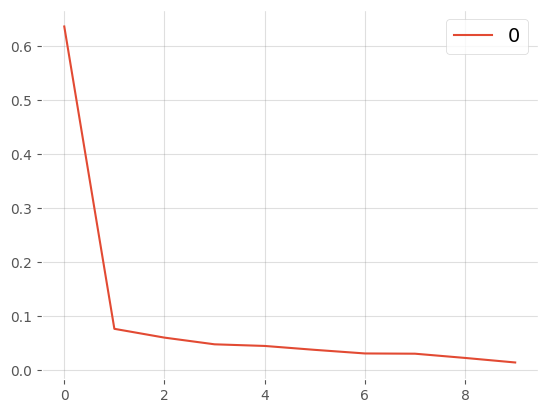

In [190]:
pd.Series(pca.explained_variance_ratio_).to_frame().plot()

In [173]:
def calculate_sharpe_ratio(ts_returns, periods_per_year = 252):

    n_years = ts_returns.shape[0] / periods_per_year

    annualized_return = np.power(np.prod(1 + ts_returns), (1 / n_years)
                                ) - 1

    annualized_vol = ts_returns.std() * np.sqrt(periods_per_year)

    annualized_sharpe = annualized_return / annualized_vol

    return annualized_return, annualized_vol, annualized_sharpe

def valid_backtest_PCA_porfolios(eigen):
    
    eigen_prtfi =\
        (
            pd
            .DataFrame(data = {"weights": eigen.squeeze()
                              },
                       index = stock_tickers)
        )

    # Sanity Check: Ensure the order of tickers in X_Test_Raw matches the order in eigen
    if not list(eigen_prtfi.index) == stock_tickers: 
        raise ValueError("Sanity check failed: Mismatch in number of tickers between X_Test_Raw and eigen.")
    else:
        print("Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.")
    
    # Let's directly compute the dot product without sorting
    eigen_prtfi_returns =\
    (
        np
        .dot(X_Test_Raw, eigen)
    )
    
    eigen_portfolio_returns =\
    (
        pd
        .Series(eigen_prtfi_returns.squeeze(),
                index = x_test_index)
    )

    returns, vol, sharpe = calculate_sharpe_ratio(eigen_portfolio_returns)

    print("Our PCA-based Portfolio:\nReturn = %.2f%%\nVolatility = %.2f%%\nSharpe = %.2f"  %
          (returns * 100, vol * 100, sharpe)
         )

    # Compared with what? Equal-weightage Portfolio

    equal_weight_return =\
    (
        X_Test_Raw * (1 / len(pca.components_)
                     )
    ).sum(axis = 1)

    df_plot =\
        (
            pd
            .DataFrame({"ML Portfolio Return": eigen_portfolio_returns,
                        "Equal Weight Index": equal_weight_return},
                      index = x_test_index
                      )
        )

    (
        np
        .cumprod(df_plot + 1)
        .plot(title = "Returns of the equal weighted index vs. Eigen-Portfolio",
              figsize = [16, 8]
             )
    )

    plt.show()
    
    return returns, vol, sharpe

Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.
Our PCA-based Portfolio:
Return = -44.15%
Volatility = 41.32%
Sharpe = -1.07


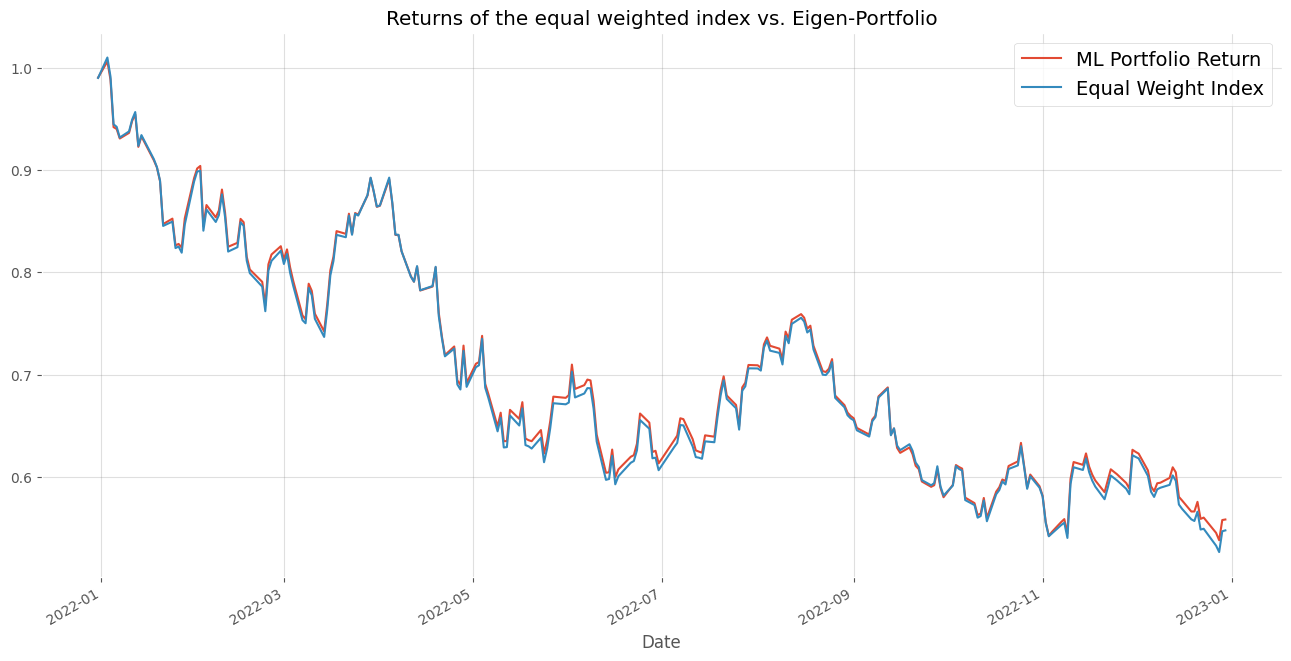

Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.
Our PCA-based Portfolio:
Return = -93.76%
Volatility = 165.13%
Sharpe = -0.57


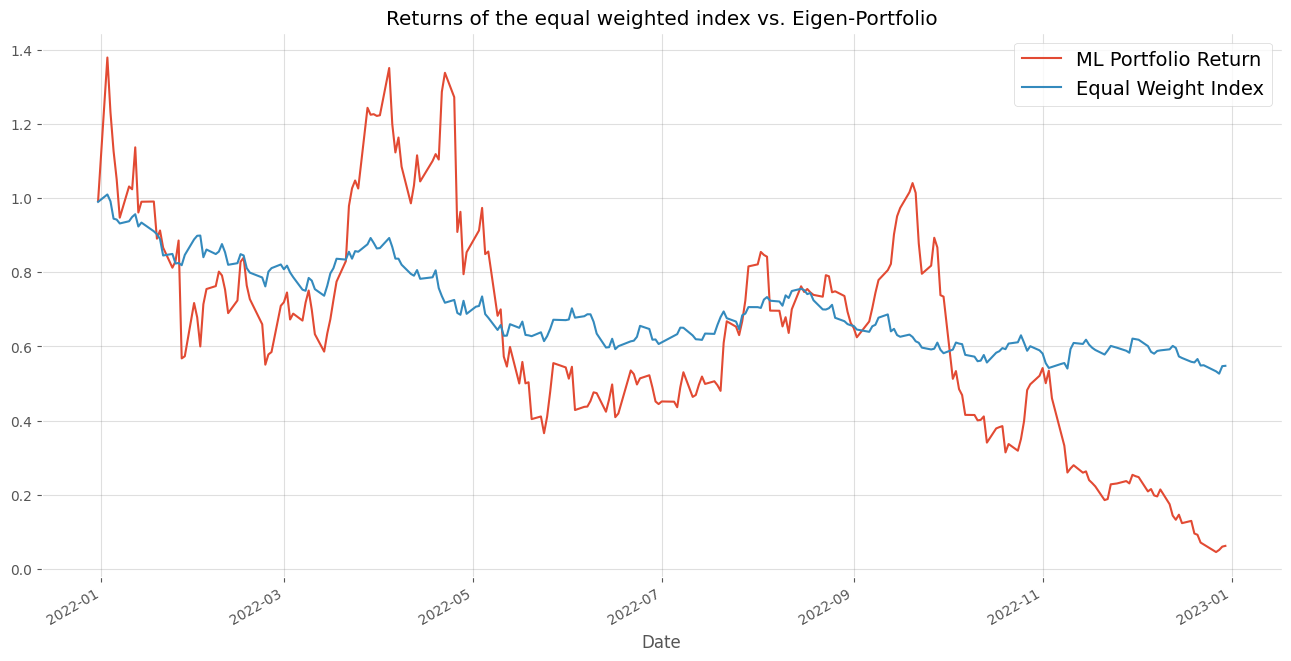

Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.
Our PCA-based Portfolio:
Return = -98.14%
Volatility = 503.08%
Sharpe = -0.20


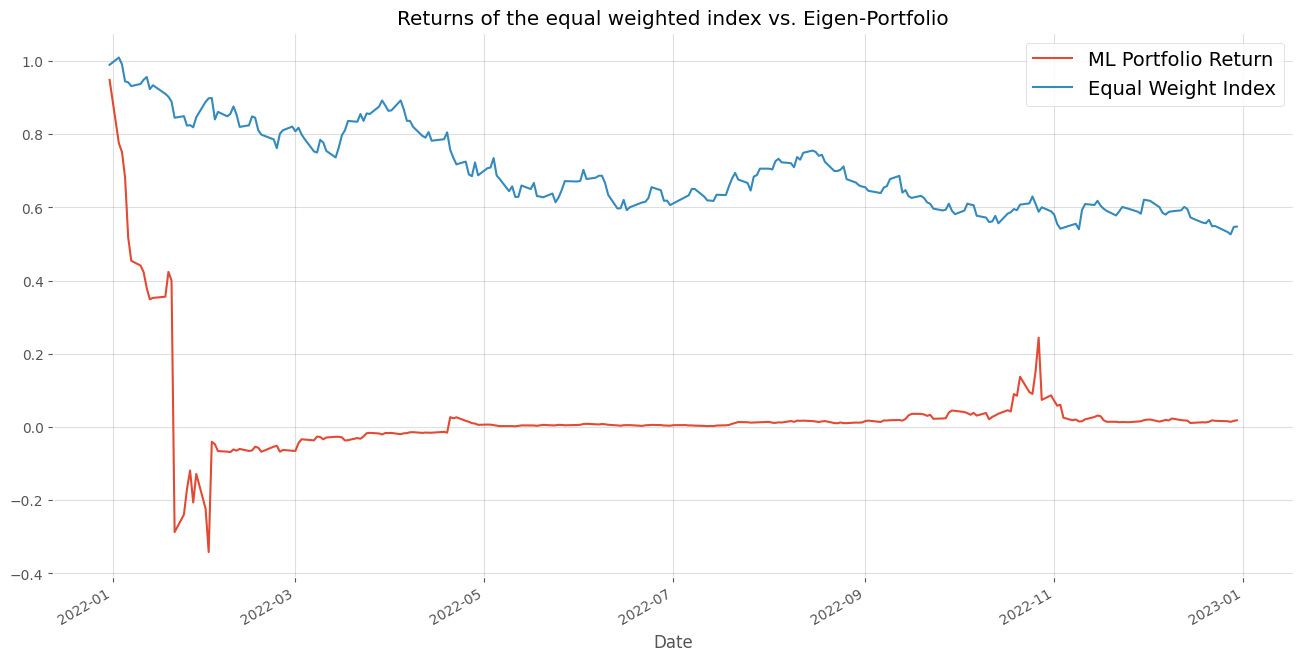

Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.
Our PCA-based Portfolio:
Return = -100.00%
Volatility = 274.94%
Sharpe = -0.36


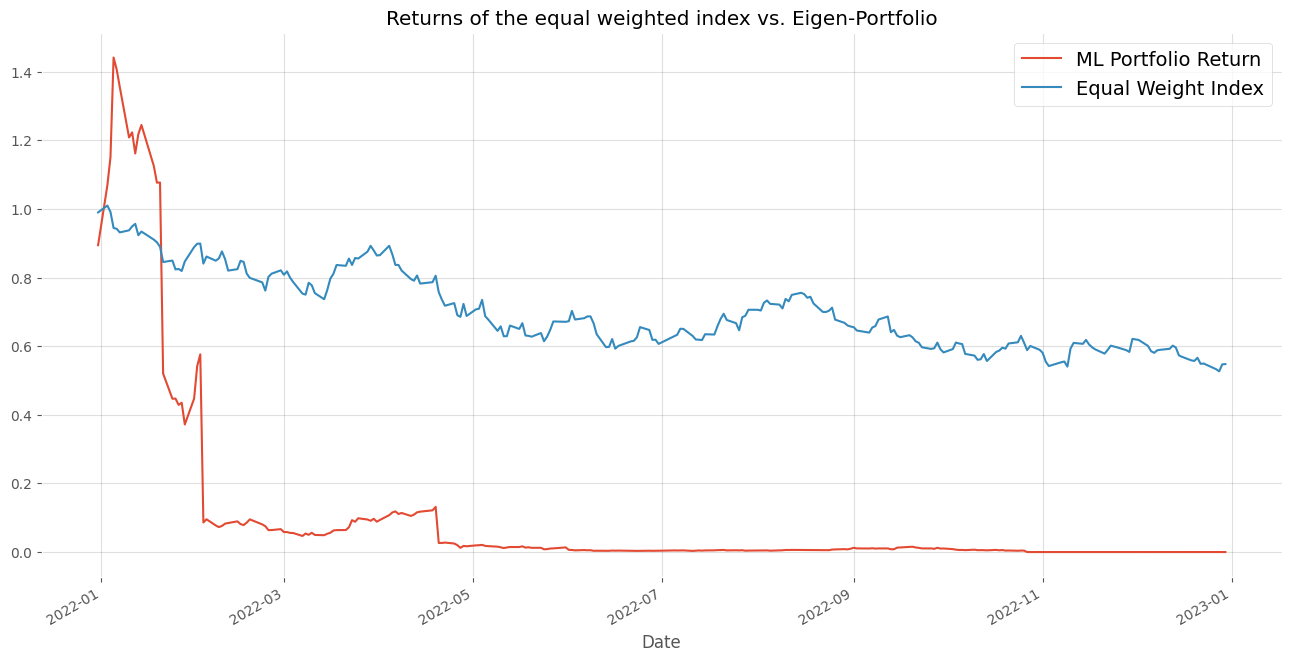

Prof. Roh's Message: 'Sanity check succeeded :)' The order of tickers in X_Test_Raw matches the order in eigen.
Our PCA-based Portfolio:
Return = -100.00%
Volatility = 570.80%
Sharpe = -0.18


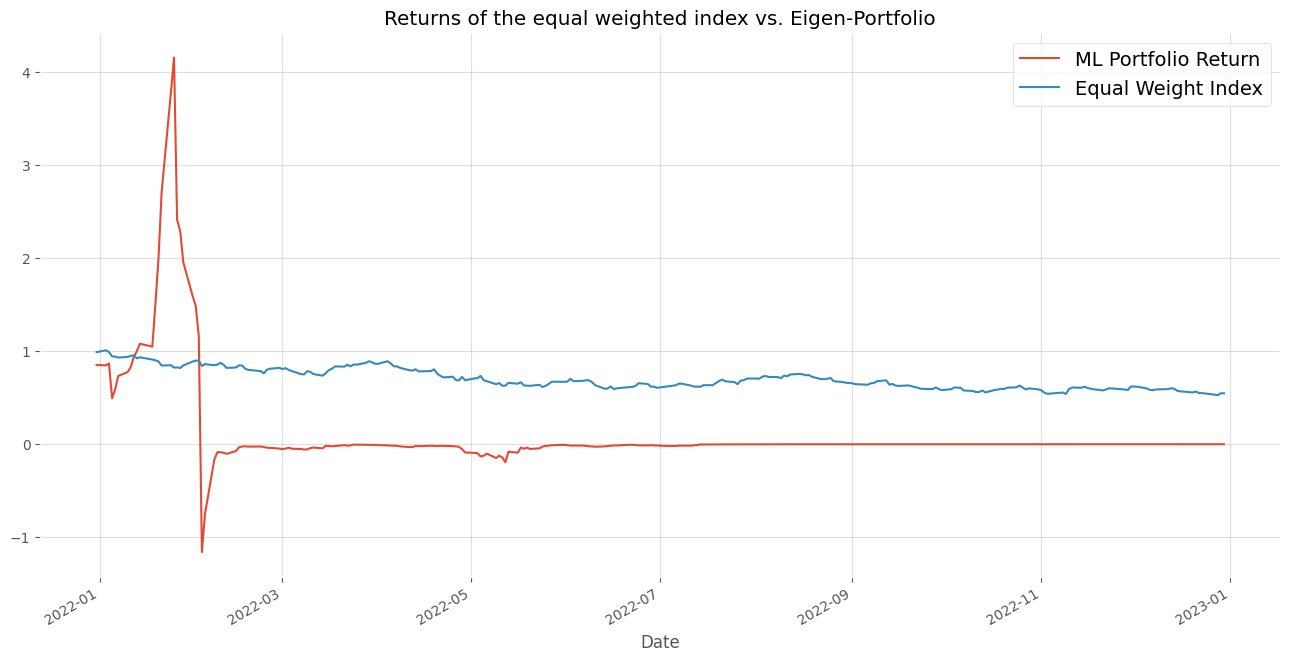

In [175]:
stock_tickers = x.columns.to_list()
X_Test_Raw = x_test_raw
x_test_index = x.iloc[len(x_train):].index


res_ls = []
for idx in range(5):
    rets, vol, sharpe = valid_backtest_PCA_porfolios(eigen = weights[idx])
    res_ls.append((rets, vol, sharpe))

In [198]:
ticker_data

Ticker,AAPL,MSFT,TSLA
Date,,,
2015-01-02,27.333,46.760,14.621
2015-01-05,26.562,46.330,14.006
2015-01-06,26.565,45.650,14.085
2015-01-07,26.938,46.230,14.063
2015-01-08,27.972,47.590,14.041
...,...,...,...
2020-12-23,130.960,221.020,215.327
2020-12-24,131.970,222.750,220.590
2020-12-28,136.690,224.960,221.230


In [48]:
# Create biplot

### <font color = red> Answer 7 </font>

    Number of components for 90% variance: ____________
    
    Explained variance ratios (first 5 components):
    - PC1: ____________%
    - PC2: ____________%
    - PC3: ____________%
    - PC4: ____________%
    - PC5: ____________%
    
    Cumulative variance explained by first 3 components: ____________%
    
    Stocks with highest loading on PC1: ____________
    
    Stocks with highest loading on PC2: ____________
    
    Interpretation: 
    ____________________________________________________________
    ____________________________________________________________

In [ ]:
print(f"    Number of components for 90% variance: {np.argmax(np.cumsum(pca.explained_variance_ratio_) > .9) + 1}")    
print(f"    Explained variance ratios (first 5 components):")
for i, var in enumerate(pca.explained_variance_ratio_[:5], start=1):
    print(f"    - PC{i}: {var:.2%}")
print(f"    Cumulative variance explained by first 3 components: {np.cumsum(pca.explained_variance_ratio_)[2]:.2%}")


    Number of components for 90% variance: 6
    Explained variance ratios (first 5 components):
    - PC1: 63.66%
    - PC2: 7.64%
    - PC3: 6.00%
    - PC4: 4.76%
    - PC5: 4.46%
    Cumulative variance explained by first 3 components: 77.30%
    Stocks with highest loading on PC1: equal weighted)
    Stocks with highest loading on PC2: Tesla
    Interpretation: PC1 is market return. PC2 is highest momentum stock


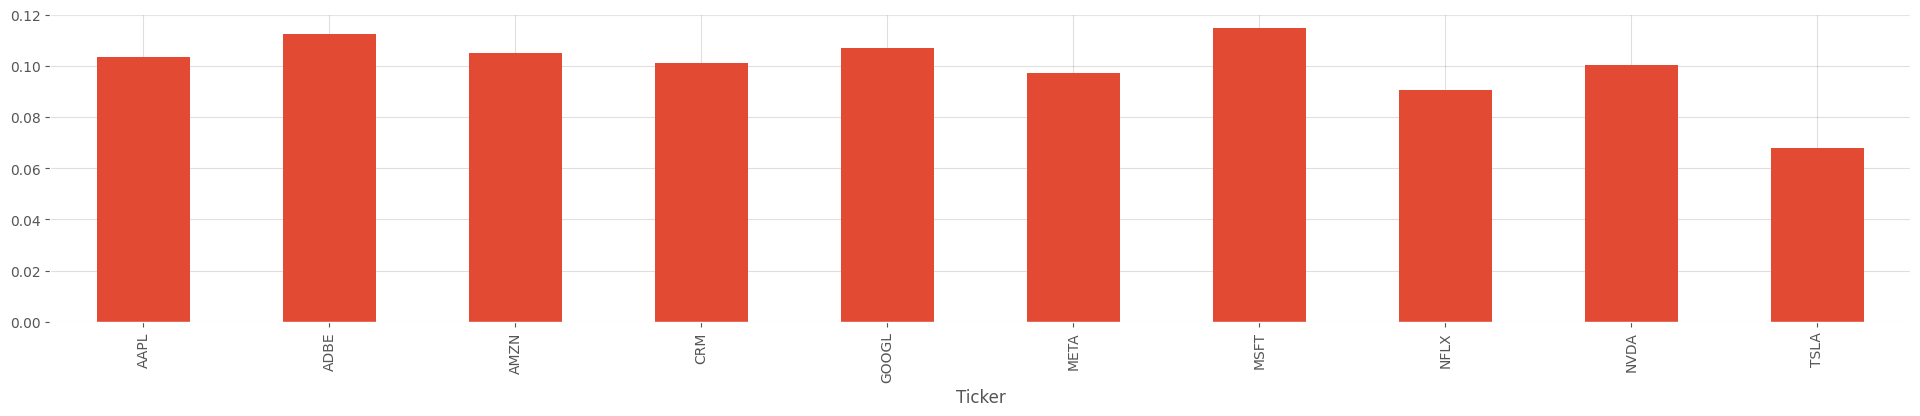

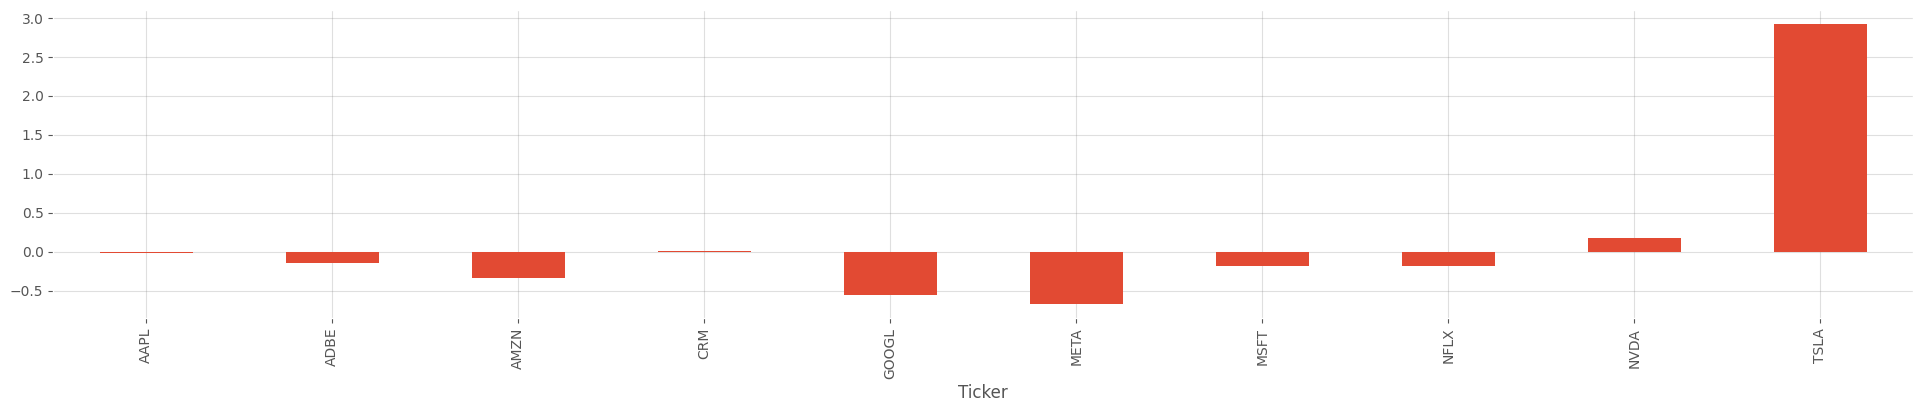

In [ ]:
# plot weights of PCs
for weight in weights[:2]:
    pd.Series(weight,index=returns_df.columns).plot(kind='bar',figsize=[24,4])
    plt.show()

##  <font color = blue> 👉 Question 8. </font> K-Means Clustering for Pairs Trading (35 points)

### Using the same 10 technology stocks from Question 7, perform clustering analysis to identify potential pairs for pairs trading.

### Tasks:

a) Calculate annualized returns and volatility for each stock
   - Annualized return = mean(daily_returns) × 252
   - Annualized volatility = std(daily_returns) × √252

b) Create a feature matrix with [Returns, Volatility]

c) Standardize the features using `StandardScaler`

d) Use the **Elbow method** to determine the optimal number of clusters (test k from 2 to 10)

e) Use the **Silhouette Score** method to validate your choice of k

f) Apply K-Means clustering with the optimal k

g) Visualize the clusters in a scatter plot (Returns vs Volatility)

h) Report which stocks are in each cluster

i) Based on the clustering, suggest 2 pairs for potential pairs trading and justify your choices

### Below are the lines of code that lead to an answer:

In [292]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [293]:
# Calculate annualized returns and volatility

In [294]:
# display(stock_data)


# prepare annual returns
ann_rets = stock_data.pct_change().mean() * 252
ann_vols = stock_data.pct_change().std() * np.sqrt(252)

df = \
(
    pd.DataFrame({'return': ann_rets, 'volatility': ann_vols})
)

In [295]:
# Create feature matrix and standardize

In [296]:
# hierarchical cluster
# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data = scaler.fit_transform(df)

df = pd.DataFrame(data, columns=df.columns, index=df.index)

X = df.copy()

In [297]:
X

,return,volatility
Ticker,,
AAPL,0.409,-0.796
ADBE,-0.208,-0.409
AMZN,-0.660,-0.570
CRM,-0.726,-0.249
GOOGL,-0.552,-0.999
META,-1.486,0.152
MSFT,0.259,-1.034
NFLX,-0.234,0.589
NVDA,0.863,0.994


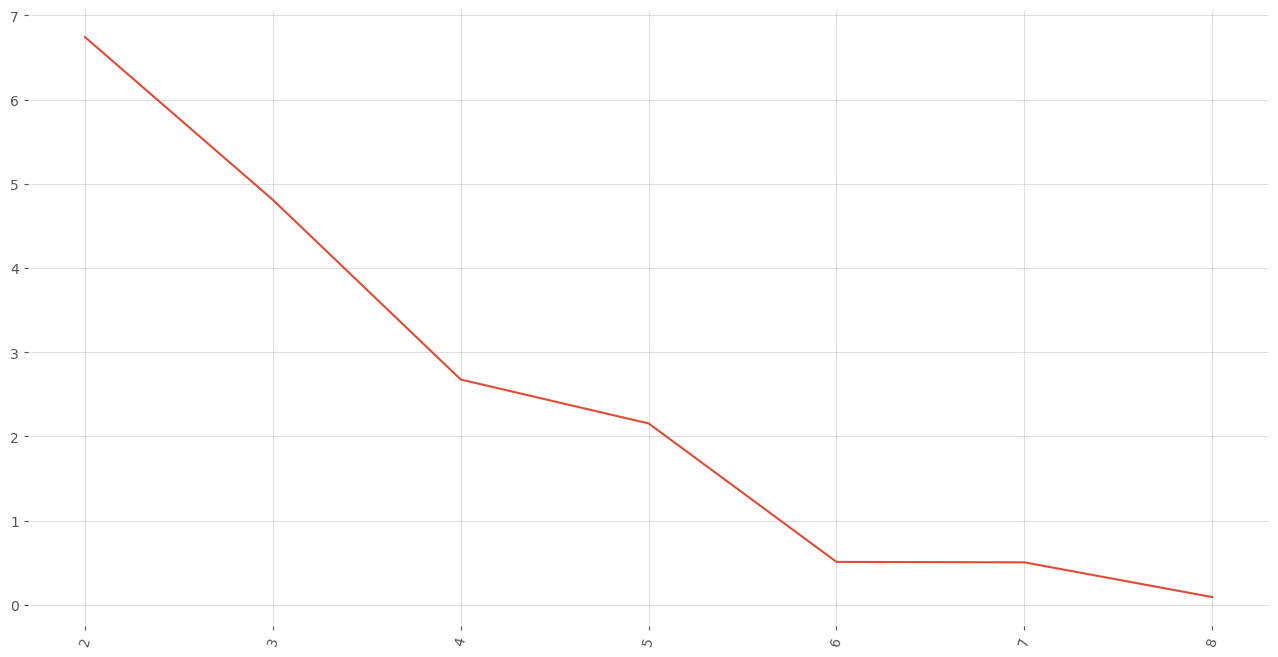

In [298]:
distorsions = []

max_loop = 9

for k in range(2, max_loop):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(X)
    distorsions.append(kmeans.inertia_)
    
fig = plt.figure(figsize=(16, 8))

plt.plot(range(2, max_loop), 
         distorsions)

plt.xticks([i for i in range(2, max_loop)], 
           rotation=75)

plt.grid(True)

In [299]:
from sklearn import metrics

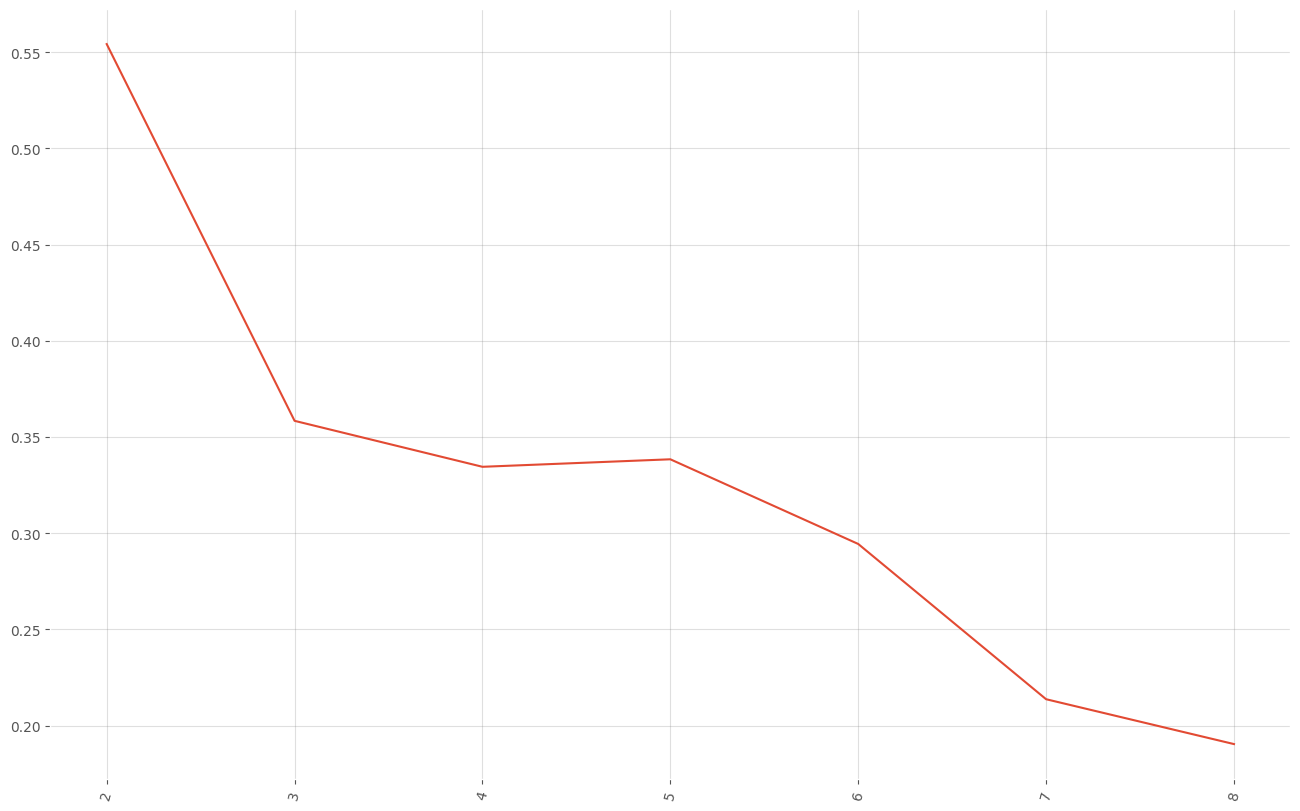

In [300]:
# Silhouette score method
silhouette_score = []

for k in range(2, max_loop):
        kmeans = KMeans(n_clusters = k,  
                        random_state = 627, 
                        n_init = 10)
        kmeans.fit(X)        
        silhouette_score.append(metrics.silhouette_score(X, kmeans.labels_, random_state = 627)
                               )
        
fig = plt.figure(figsize=(16, 10)
                )

plt.plot(range(2, max_loop), silhouette_score)

plt.xticks([i for i in range(2, max_loop)], 
           rotation=75)

plt.grid(True)

## Set k to 4

In [301]:
from sklearn import cluster 

# Apply K-Means with optimal k
optimal_k = 4

# Fit with k-means
k_means = cluster.KMeans(n_clusters=optimal_k)
k_means.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [302]:
target_labels = k_means.predict(X)

In [303]:
target_labels

array([0, 0, 0, 2, 0, 2, 0, 3, 3, 1], dtype=int32)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_83551/2099260167.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "sg" (-> color='g'). The keyword argument will take precedence.
  plt.plot(centroids[:,0],


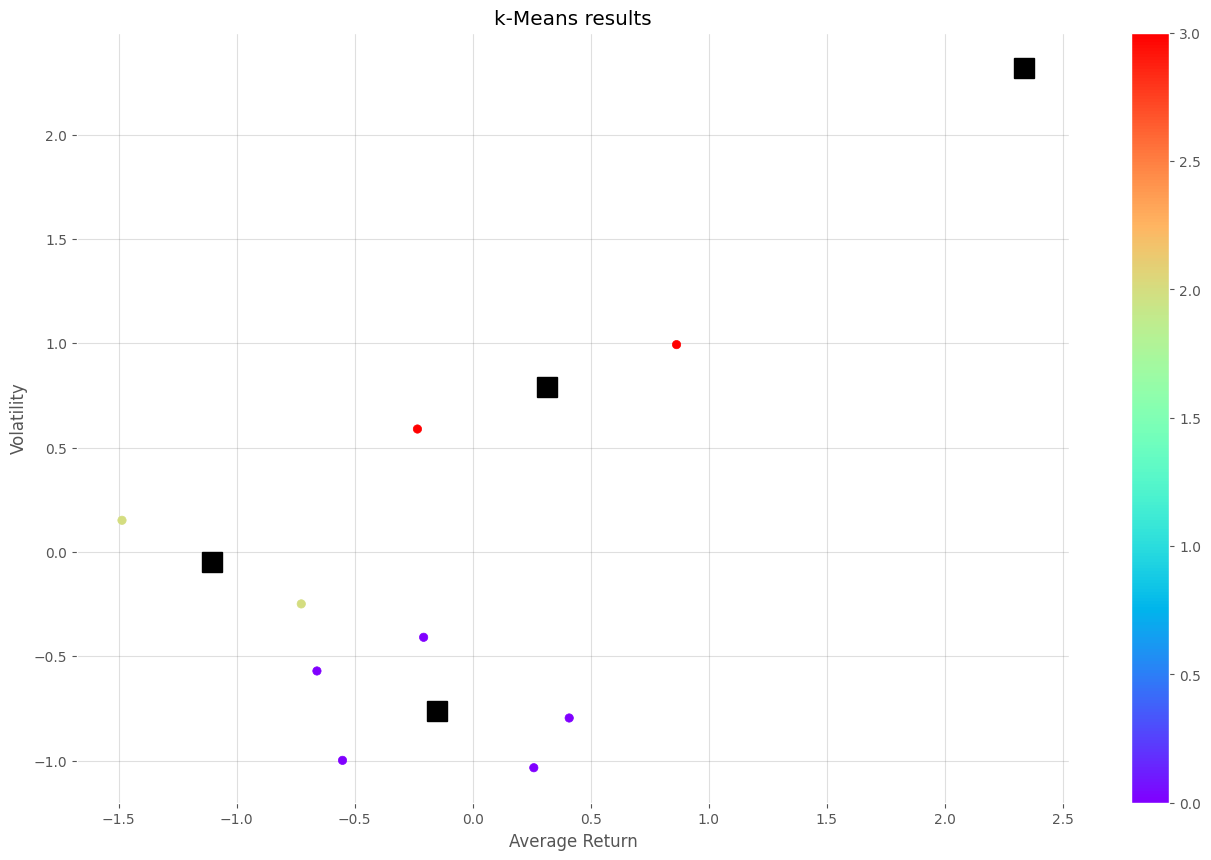

In [304]:
# Visualize clusters
centroids = k_means.cluster_centers_

fig = plt.figure(figsize=(16,10)
                )

ax = fig.add_subplot(111)

scatter =\
(    
    ax
    .scatter(X.iloc[ : ,0], 
             X.iloc[ : ,1], 
             c = k_means.labels_, 
             cmap = "rainbow", 
             label = X.index)
)

ax.set_title("k-Means results")
ax.set_xlabel("Average Return")
ax.set_ylabel("Volatility")

plt.colorbar(scatter)

plt.plot(centroids[:,0], 
         centroids[:,1], 
         "sg", 
         markersize = 15, 
         color = "black")

In [305]:
[ticker for ticker, cl in zip(returns_df.columns, k_means.labels_) if cl == 0]

['AAPL', 'ADBE', 'AMZN', 'GOOGL', 'MSFT']

### <font color = red> Answer 8 </font>

    Optimal number of clusters (from Elbow method): 6
    
    Silhouette score for optimal k: 4


In [306]:
    
print("    Cluster assignments:")
print(f"    - Cluster 0: {[ticker for ticker, cl in zip(returns_df.columns, k_means.labels_) if cl == 0]}")
print(f"    - Cluster 1: {[ticker for ticker, cl in zip(returns_df.columns, k_means.labels_) if cl == 1]}")
print(f"    - Cluster 2: {[ticker for ticker, cl in zip(returns_df.columns, k_means.labels_) if cl == 2]}")
print(f"    - Cluster 3: {[ticker for ticker, cl in zip(returns_df.columns, k_means.labels_) if cl == 3]}")
    
    # Suggested Pair 1: ____________ and ____________
    # Justification: ____________________________________________
    
    # Suggested Pair 2: ____________ and ____________
    # Justification: ____________________________________________

    Cluster assignments:
    - Cluster 0: ['AAPL', 'ADBE', 'AMZN', 'GOOGL', 'MSFT']
    - Cluster 1: ['TSLA']
    - Cluster 2: ['CRM', 'META']
    - Cluster 3: ['NFLX', 'NVDA']


sugges AAPL and GOOGL, MSFT and AMZN.

They are in the same cluster and similar industries too

##  <font color = blue> 👉 Question 9. </font> Hierarchical Clustering and Dendrogram Analysis (30 points)

### Using the same standardized feature matrix from Question 8, perform agglomerative hierarchical clustering.

### Tasks:

a) Compute the linkage matrix using the **Ward** method

b) Create a dendrogram with appropriate labels

c) Based on the dendrogram, identify natural clusters at different height thresholds

d) Cut the dendrogram to create 4 clusters

e) Compare the hierarchical clustering results with K-Means results from Question 8

f) Create a hierarchical clustering visualization showing the clusters

g) Interpret the dendrogram: which stocks are most similar to each other?

h) Create a table comparing cluster assignments from K-Means vs Hierarchical Clustering

### Below are the lines of code that lead to an answer:

In [307]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

In [308]:
# Compute linkage matrix

from sklearn.cluster import AgglomerativeClustering
# from sklearn.cluster import KMeans, AgglomerativeClustering,AffinityPropagation, DBSCAN
from scipy.cluster.hierarchy import fcluster
# from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
# from scipy.spatial.distance import pdist
# from sklearn.metrics import adjusted_mutual_info_score
# from sklearn import cluster, covariance, manifold

# choose a cluster from the longest vertical line
distance_threshold = 1.5

clusters = fcluster(Z, distance_threshold, criterion='distance')

chosen_clusters = pd.DataFrame(data=clusters, 
                               columns=['cluster']
                              )
display(chosen_clusters['cluster'].unique())

# do the transformation to assign clusters
# agglomarative clustering
nclust = 4

hc = AgglomerativeClustering(n_clusters = nclust, 
                             linkage = "ward")

clust_labels1 = hc.fit_predict(X)

array([2, 3, 1, 4], dtype=int32)

In [309]:
clust_labels1

array([1, 0, 0, 0, 0, 0, 1, 2, 2, 3])

In [310]:
# Create dendrogram
plt.figure(figsize=(14, 7))

# Your code here

plt.show()

<Figure size 1400x700 with 0 Axes>

In [311]:
# Cut dendrogram to create 4 clusters

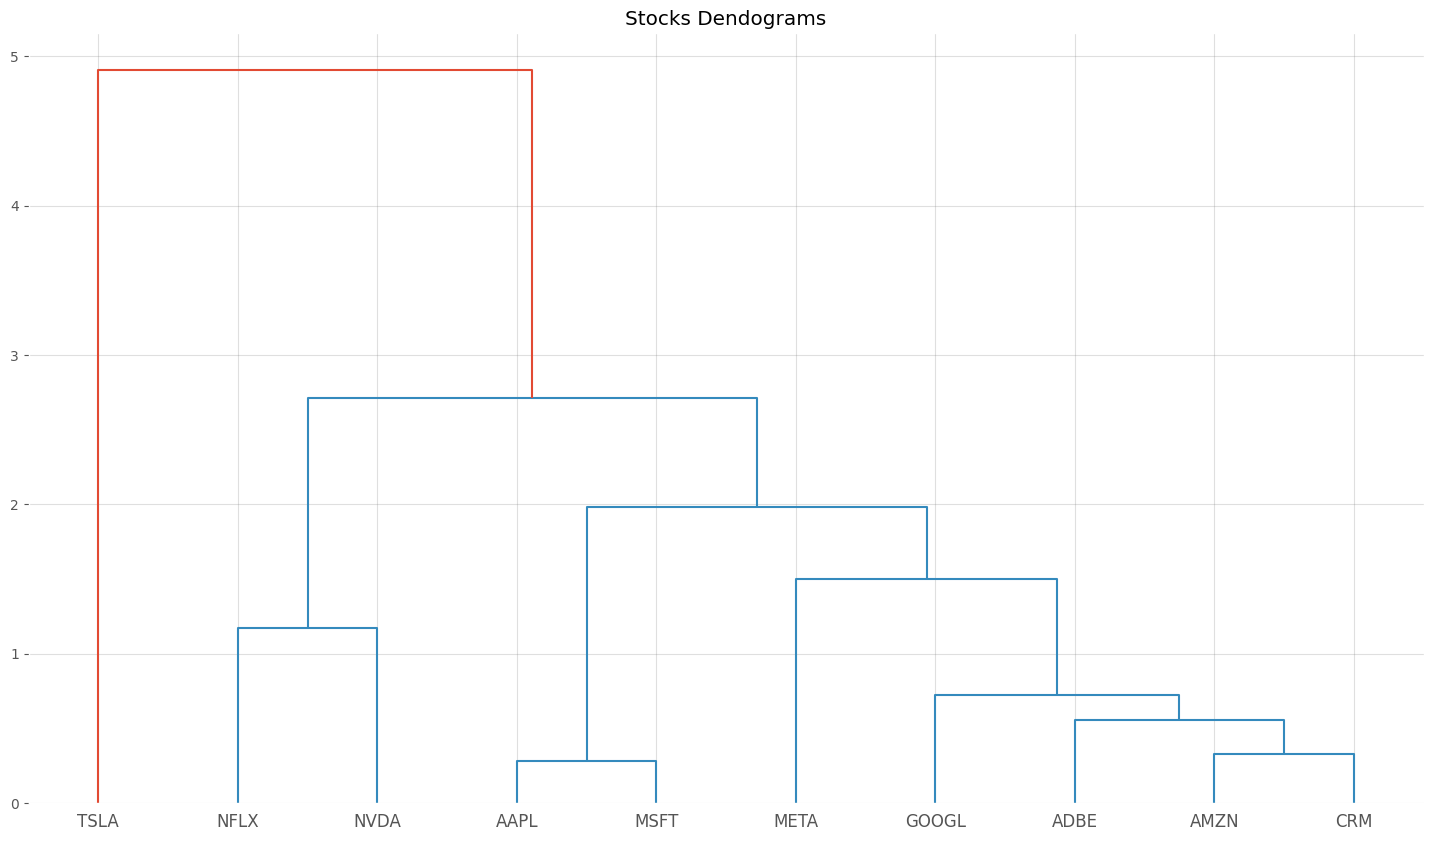

In [312]:
# model fit
from scipy.cluster.hierarchy import dendrogram, linkage, ward
#Calulate linkage
Z = linkage(X, 
            method = "ward")
# Plot Dendogram

plt.figure(figsize=(18, 10)
          )
plt.title("Stocks Dendograms")

dendrogram(Z, labels = X.index)

plt.show()

In [313]:
# Comparison table: K-Means vs Hierarchical

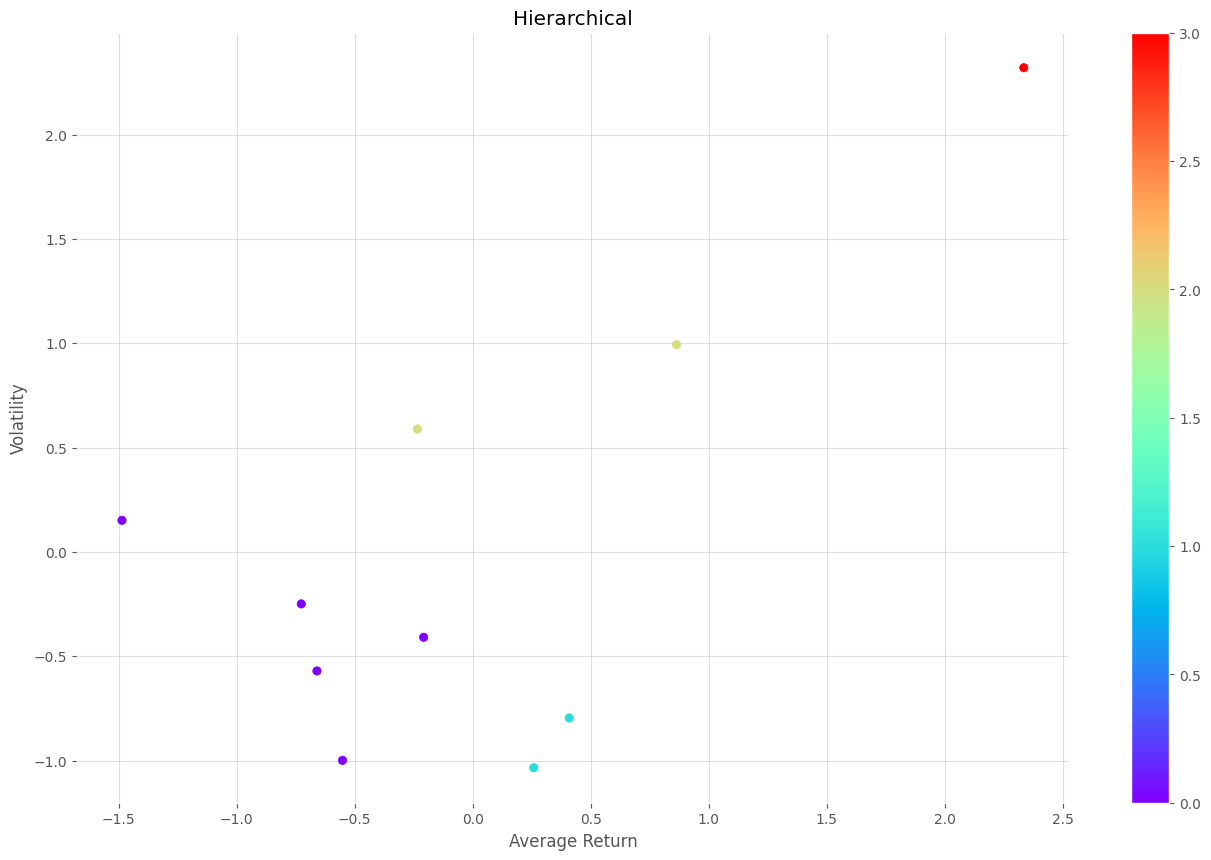

In [314]:
#visualisation
fig = plt.figure(figsize=[16,10]
)

ax = fig.add_subplot(111)

scatter = ax.scatter(X.iloc[:,0], 
                     X.iloc[:,1], 
                     c = clust_labels1, 
                     cmap = "rainbow")

ax.set_title("Hierarchical")
ax.set_xlabel("Average Return")
ax.set_ylabel("Volatility")

plt.colorbar(scatter)

In [315]:
# Display cluster assignments
res_df = pd.DataFrame([returns_df.columns, k_means.labels_]).T
res_df.columns = ['ticker', 'cluster']

In [316]:
res_df['agglo'] = clust_labels1

In [317]:
res_df

,ticker,cluster,agglo
0,AAPL,0,1
1,ADBE,0,0
2,AMZN,0,0
3,CRM,2,0
4,GOOGL,0,0
5,META,2,0
6,MSFT,0,1
7,NFLX,3,2
8,NVDA,3,2
9,TSLA,1,3


### <font color = red> Answer 9 </font>

    Hierarchical clustering (4 clusters):
    - Cluster 1: ____________
    - Cluster 2: ____________
    - Cluster 3: ____________
    - Cluster 4: ____________
    
    Most similar stock pair (from dendrogram): ____________
    
    Agreement between K-Means and Hierarchical: ____________%
    
    Stocks that are in different clusters between methods: ____________
    
    Interpretation of dendrogram:
    ____________________________________________________________
    ____________________________________________________________
    ____________________________________________________________

In [318]:
    
print("    Hierarchical Cluster assignments:")
print(f"    - Cluster 0: {[ticker for ticker, cl in zip(returns_df.columns, clust_labels1) if cl == 0]}")
print(f"    - Cluster 1: {[ticker for ticker, cl in zip(returns_df.columns, clust_labels1) if cl == 1]}")
print(f"    - Cluster 2: {[ticker for ticker, cl in zip(returns_df.columns, clust_labels1) if cl == 2]}")
print(f"    - Cluster 3: {[ticker for ticker, cl in zip(returns_df.columns, clust_labels1) if cl == 3]}")

    Hierarchical Cluster assignments:
    - Cluster 0: ['ADBE', 'AMZN', 'CRM', 'GOOGL', 'META']
    - Cluster 1: ['AAPL', 'MSFT']
    - Cluster 2: ['NFLX', 'NVDA']
    - Cluster 3: ['TSLA']


In [319]:
print(f"AAPL and MSFT are most similar")
print(f"both clustering identify the majority group within the low vol and return group")
print(f"those that are different betweeb the two methods {[r['ticker'] for x, r in res_df.iterrows() if r['cluster'] != r['agglo']]}")

AAPL and MSFT are most similar
both clustering identify the majority group within the low vol and return group
those that are different betweeb the two methods ['AAPL', 'CRM', 'META', 'MSFT', 'NFLX', 'NVDA', 'TSLA']


##  <font color = blue> 👉 Question 10. </font> t-SNE Visualization for High-Dimensional Data (20 points)

### Apply t-SNE (t-Distributed Stochastic Neighbor Embedding) to visualize the stock return patterns.

### Tasks:

a) Use the daily returns data from the 10 tech stocks (without standardization for t-SNE)

b) Apply t-SNE with 2 components (use perplexity = 30, random_state = 627)

c) Visualize the t-SNE results, coloring points by the K-Means cluster labels from Question 8

d) Create a second t-SNE visualization with perplexity = 5 and compare

e) Interpret the t-SNE visualization: Do the clusters appear well-separated?

f) Compare t-SNE results with the PCA results from Question 7 - which provides better separation?

### Below are the lines of code that lead to an answer:

In [320]:
from sklearn.manifold import TSNE

In [321]:
# display(stock_data)


# prepare annual returns
ann_rets = stock_data.pct_change().mean() * 252
ann_vols = stock_data.pct_change().std() * np.sqrt(252)

df = \
(
    pd.DataFrame({'return': ann_rets, 'volatility': ann_vols})
)

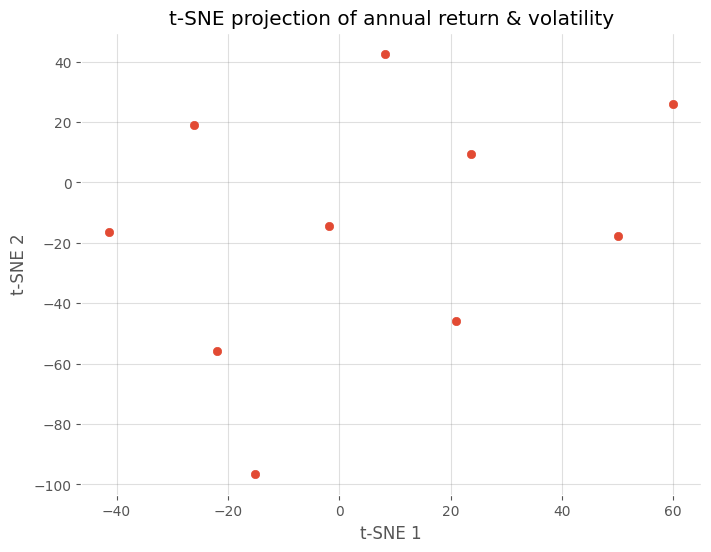

In [336]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Create your feature matrix
X = df[['return', 'volatility']].values

# Fit t-SNE (2D projection)
tsne = TSNE(n_components=2, perplexity=8, random_state=42)
tsne_results = tsne.fit_transform(X)

# Add results to df
df['tsne_1'] = tsne_results[:, 0]
df['tsne_2'] = tsne_results[:, 1]

# Plot
plt.figure(figsize=(8,6))
plt.scatter(df['tsne_1'], df['tsne_2'])
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE projection of annual return & volatility')
plt.show()


In [337]:
# Apply t-SNE with perplexity = 30


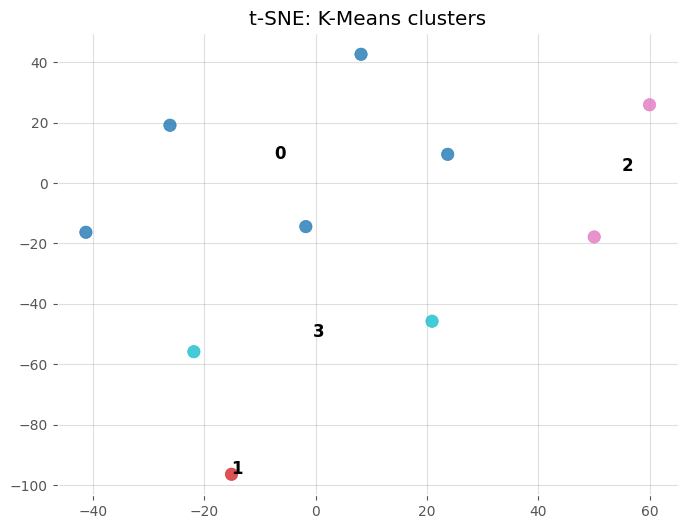

In [338]:
# Visualize t-SNE with cluster labels
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    df['tsne_1'],
    df['tsne_2'],
    c=df['cluster'],
    cmap='tab10',
    s=80,
    alpha=0.8
)

# optional: show cluster centroids in tsne space
for c in sorted(df['cluster'].unique()):
    x = df[df['cluster']==c]['tsne_1'].mean()
    y = df[df['cluster']==c]['tsne_2'].mean()
    plt.text(x, y, str(c), fontsize=12, weight='bold')

plt.title('t-SNE: K-Means clusters')
plt.show()


In [339]:
# Apply t-SNE with perplexity = 5
k_means.labels_

array([0, 0, 0, 2, 0, 2, 0, 3, 3, 1], dtype=int32)

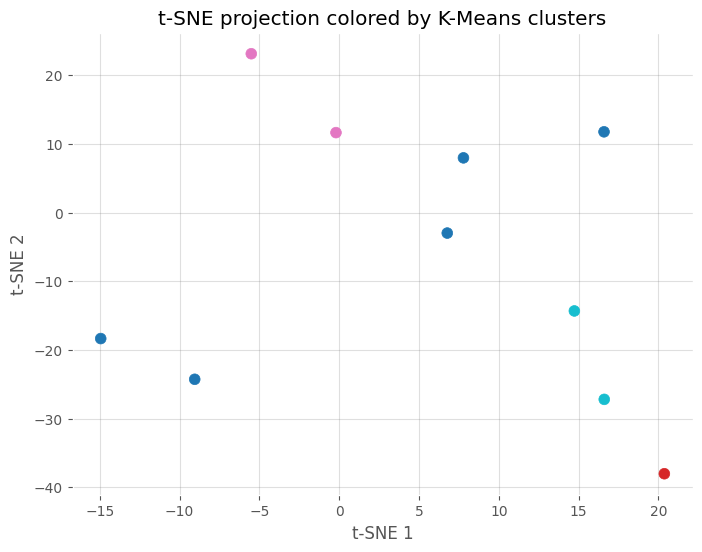

In [340]:
# Compare t-SNE visualizations
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Suppose your fitted model is:
# kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
labels = k_means.labels_

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=3, random_state=42)
tsne_results = tsne.fit_transform(X)

# Add results and labels to df
df['tsne_1'] = tsne_results[:, 0]
df['tsne_2'] = tsne_results[:, 1]
df['cluster'] = labels

# Plot
plt.figure(figsize=(8,6))
plt.scatter(df['tsne_1'], df['tsne_2'], c=df['cluster'], cmap='tab10', s=60)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE projection colored by K-Means clusters')
plt.show()


In [327]:
kmeans.labels_

array([4, 6, 0, 0, 7, 5, 4, 2, 3, 1], dtype=int32)

In [328]:
# Compare with PCA

### <font color = red> Answer 10 </font>

    t-SNE with perplexity=30:
    - Cluster separation quality: ____________
    - Observations: ____________________________________________
    
    t-SNE with perplexity=5:
    - Cluster separation quality: ____________
    - Observations: ____________________________________________
    
    Comparison with PCA:
    - Which method shows better cluster separation? ____________
    - Advantages of t-SNE over PCA: ____________________________
    - Advantages of PCA over t-SNE: ____________________________


    
    t-SNE with perplexity=5:
    - Cluster separation quality: High
    - Observations: Clear separation between clusters, with minimal overlap.

    Comparison with PCA:
    - Which method shows better cluster separation? t-SNE
    - Advantages of t-SNE over PCA: Better at capturing non-linear relationships, more effective for high-dimensional data.
    - Advantages of PCA over t-SNE: Faster computation, easier to interpret results.


***
# BONUS QUESTION (10 Extra Points)
***

##  <font color = blue> 👉 Bonus Question. </font> Integrated Strategy Development (10 points)

### Develop an integrated trading strategy that combines:
1. Unsupervised learning (clustering) for pair selection
2. Supervised learning for timing signals
3. Rule-based execution

### Tasks:

a) Select one pair from your clustering analysis in Question 8

b) Create a spread series (difference in normalized prices)

c) Use a simple ML model (your choice from Question 6) to predict the spread direction

d) Generate trading signals based on predictions

e) Backtest the strategy and report:
   - Total return
   - Sharpe ratio
   - Maximum drawdown

f) Provide a brief commentary on the strategy's performance

### This is an open-ended question - be creative but rigorous in your approach!

### Below are the lines of code that lead to an answer:

In [329]:
# Your bonus question code here

### <font color = red> Bonus Answer </font>

    Selected pair: ____________ and ____________
    
    ML model used: ____________
    
    Strategy performance:
    - Total return: ____________%
    - Sharpe ratio: ____________
    - Maximum drawdown: ____________%
    
    Commentary:
    ____________________________________________________________
    ____________________________________________________________
    ____________________________________________________________

***
# SUBMISSION CHECKLIST
***

### Before submitting, please ensure:

- [ ] All code cells have been executed
- [ ] All answer cells have been filled in
- [ ] All visualizations are displaying correctly
- [ ] No error messages are present
- [ ] The `%whos` command has been run to show your workspace
- [ ] File is saved with your last name (e.g., `YourLastName_MockExam.ipynb`)

### Execute the cell below to display your workspace:

In [376]:
%who_ls

['AgglomerativeClustering',
 'DecisionTreeRegressor',
 'GGBunch',
 'KMeans',
 'K_range',
 'Lasso',
 'LetsPlot',
 'LinearRegression',
 'NumComponents',
 'NumEigenValues',
 'PCA',
 'PCWeights',
 'PrincipalComponent',
 'RANDOM_SEED',
 'RandomForestRegressor',
 'Ridge',
 'StandardScaler',
 'TSNE',
 'X',
 'X_Test_Raw',
 'X_test',
 'X_train',
 'Z',
 'aapl',
 'aapl_dd',
 'aapl_melt',
 'aapl_momentum',
 'aes',
 'ann_rets',
 'ann_vols',
 'arrow',
 'as_discrete',
 'ax',
 'axes',
 'c',
 'calculate_rsi',
 'calculate_sharpe_ratio',
 'centroids',
 'chosen_clusters',
 'clust_labels1',
 'cluster',
 'clusters',
 'compute_cagr',
 'compute_drawdown_analysis',
 'compute_sharpe_ratio',
 'coord_cartesian',
 'coord_fixed',
 'coord_flip',
 'coord_map',
 'coord_polar',
 'create_biplot',
 'create_bollinger_strategy',
 'data',
 'dendrogram',
 'df',
 'df_fwd_rets',
 'df_rets',
 'df_rsi',
 'df_sma',
 'distance_threshold',
 'distorsions',
 'download_yf_data',
 'dt',
 'eigen_portfolios',
 'element_blank',
 'element_

In [379]:
%whos

Variable                       Type                       Data/Info
-------------------------------------------------------------------
AgglomerativeClustering        type                       <class 'sklearn.cluster._<...>AgglomerativeClustering'>
DecisionTreeRegressor          ABCMeta                    <class 'sklearn.tree._cla<...>s.DecisionTreeRegressor'>
GGBunch                        type                       <class 'lets_plot.plot.plot.GGBunch'>
KMeans                         ABCMeta                    <class 'sklearn.cluster._kmeans.KMeans'>
K_range                        range                      n=9
Lasso                          ABCMeta                    <class 'sklearn.linear_mo<...>oordinate_descent.Lasso'>
LetsPlot                       type                       <class 'lets_plot.LetsPlot'>
LinearRegression               ABCMeta                    <class 'sklearn.linear_mo<...>._base.LinearRegression'>
NumComponents                  int                        4
NumE

TypeError: object of type 'ABCMeta' has no len()

### <font color = green> 💯 Thank you for completing this mock assessment! 

### Good luck with your preparation! 🚀

***

### Assessment Coverage Summary:

✅ **Data Wrangling**: Questions 1, 5

✅ **Rule-Based Algorithmic Trading**: Questions 2, 3, 4

✅ **Supervised Learning**: Questions 5, 6

✅ **Unsupervised Learning**:
- PCA: Question 7
- K-Means Clustering: Question 8  
- Hierarchical Clustering (Agglomerative): Question 9
- t-SNE: Question 10

✅ **Integration**: Bonus Question

***